# DESI DR2 Calibration but on CF4 Data

This notebook runs the same calibration we run for the DESI DR2 TF Calibration (v5), but using the CF4 data

In [2]:
import numpy as np

import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = False
from matplotlib import cm, colors
from matplotlib.patches import Ellipse
import matplotlib as mpl

# We have more than 10 redshift bins, so we need to change the default color map so that they are all plotted with different colors
# from cycler import cycler
# plt.rcParams['axes.prop_cycle'] = cycler('color', plt.get_cmap('tab20').colors)

import ligo.skymap.plot

from astropy.table import Table, vstack, join
from astropy.coordinates import SkyCoord, Distance
from astropy.cosmology import Planck18, FlatLambdaCDM
from astropy.wcs import WCS
from astropy.visualization.wcsaxes import SphericalCircle
from astropy import units as u
from astropy import constants as c
from astropy import constants as const
from astropy.io import fits

from cosmoprimo.fiducial import DESI

from scipy.spatial.distance import cdist, euclidean

import os

from corner import corner, hist2d
import math
import pickle

from sklearn.covariance import EllipticEnvelope
from matplotlib.patches import Ellipse
from scipy.stats import chi2

from tqdm import tqdm
from hdbscan import HDBSCAN
from scipy.stats import binned_statistic
from matplotlib.projections import get_projection_names

from desiutil.plots import init_sky

# Custom functions / classes
import sys
# sys.path.insert(1, '/global/u1/k/kadglass/DESI_SGA/TF/')
# sys.path.insert(1, '/Users/kdouglass/Documents/Research/DESI/PV_survey/code/TF/')
sys.path.insert(1, '/global/u1/s/sgmoore1/DESI_SGA/TF/')
from help_functions import adjust_lightness
from line_fits import hyperfit_line_multi
from TF_photoCorrect import BASS_corr, MW_dust, k_corr, internal_dust
from z_CMB_convert import convert_z_frame

In [3]:
# Base values for later conversions (all in units in km/s).
c_kms = c.c.to_value('km/s')

h = 1.
# H0 = 100*h
H0=75*h

q0 = 0.2

# Access CF Data

In [7]:
CF4_directory = '../Y1/CF4/'

cftab1 = Table.read(CF4_directory + 'table1.fits')
cftab4 = Table.read(CF4_directory + 'table4.fits')
cf4 = join(cftab1, cftab4, keys=['PGC'])
cf4
# ### Simplify down to any column that may be relevant
cf4 = Table.from_pandas(cf4[['PGC', 'Inc', 'e_Inc', 'Wmx', 'e_Wmx', 'logWmxi', 'e_logWmxi', 'm21', 'e_m21', 'gmag', 'rmag', 'imag', '__b_a_s', 'gcmag', 'rcmag', 'icmag', 'Ag', 'e_Ag',
           'Ar', 'e_Ar' , 'Ai', 'e_Ai', 'g_mag', 'r_mag', 'i_mag', '_RA', '_DE', 'Vls', 'Vcmb', 'DM-r', 'e_DM-r', 'DM-i', 'e_DM-i']].to_pandas().dropna())

In [8]:
Planck18_h = FlatLambdaCDM(H0=75, Om0=0.3151)

## Calculate CMB redshift

In [9]:
cf4['Z_CMB'] = np.sqrt((1 + cf4['Vcmb']/c_kms)/(1 - cf4['Vcmb']/c_kms))-1

## Rename photometrically corrected magnitude columns

In [10]:
cf4['R_MAG_CORR'] = cf4['r_mag']
cf4['G_MAG_CORR'] = cf4['g_mag']
cf4['I_MAG_CORR'] = cf4['i_mag']

In [11]:
# Compute my best guess of the uncertainties based on the columns in their tables
cf4['R_MAG_ERR_CORR'] = np.sqrt(cf4['e_m21']**2 + cf4['e_Ar']**2)
cf4['G_MAG_ERR_CORR'] = np.sqrt(cf4['e_m21']**2 + cf4['e_Ag']**2)
cf4['G_MAG_ERR_CORR'] = np.sqrt(cf4['e_m21']**2 + cf4['e_Ai']**2)

# Redshift bins

Separate the galaxies into redshift bins of width 0.005, starting at a redshift of 0 since this is how we will ultimately calibrate the sample.

In [12]:
zmin=0
zmax = 0.05
dz = 0.005
zbins = np.arange(zmin, zmax+dz/2, dz)

zbin_indices = np.digitize(cf4['Z_CMB'], zbins, right=True)
binwidth=dz

In [13]:
for i in range(len(zbins) + 1):
    if i == 0:
        print(f'{i:2d}  z <= {zbins[i]:0.3f}  {np.sum(zbin_indices == i):3d} galaxies')
    elif i == len(zbins):
        print(f'{i:2d}  z > {zbins[i-1]:0.3f}  {np.sum(zbin_indices == i):3d} galaxies')
    else:
        print(f'{i:2d}  {zbins[i-1]:0.3f} < z <= {zbins[i]:0.3f}  {np.sum(zbin_indices == i):3d} galaxies')

 0  z <= 0.000    0 galaxies
 1  0.000 < z <= 0.005  322 galaxies
 2  0.005 < z <= 0.010  768 galaxies
 3  0.010 < z <= 0.015  843 galaxies
 4  0.015 < z <= 0.020  1268 galaxies
 5  0.020 < z <= 0.025  1281 galaxies
 6  0.025 < z <= 0.030  844 galaxies
 7  0.030 < z <= 0.035  622 galaxies
 8  0.035 < z <= 0.040  425 galaxies
 9  0.040 < z <= 0.045  221 galaxies
10  0.045 < z <= 0.050  101 galaxies
11  z > 0.050   74 galaxies


# Apply Cuts Suitable for Calibrating the TFR

Requirements:
* Not a dwarf

It seems like the other outliers may have been removed from the sample, because the Table 4 with the fit values is smaller than Table 1 with the overall galaxy population.

In [15]:
cosmo = FlatLambdaCDM(H0=75, Om0=0.3151)
cf4['MU_ZCMB'] = cosmo.distmod(cf4['Z_CMB'].value)
cf4['R_ABSMAG'] = cf4['R_MAG_CORR'] - cf4['MU_ZCMB'].value
cf4['I_ABSMAG'] = cf4['I_MAG_CORR'] - cf4['MU_ZCMB'].value

In [16]:
zmin=0.01
zmax = 0.05
dz = 0.005
zbins = np.arange(zmin, zmax+dz/2, dz)

zbin_indices = np.digitize(cf4['Z_CMB'], zbins, right=True)
cf4['Z_BIN_IDX'] = zbin_indices
binwidth=dz

In [17]:
is_not_dwarf = cf4['I_ABSMAG'] < -17
outlier_boolean = ~is_not_dwarf

cf4['MAIN'] = is_not_dwarf


In [18]:
zmin=0.01
# zmin = 0.03
zmax = 0.05
dz = 0.005
zbins = np.arange(zmin, zmax+dz/2, dz)

# zbin_indices = np.digitize(cf4['Z_CMB'][~outlier_boolean], zbins, right=True)
zbin_indices = np.digitize(cf4['Z_CMB'], zbins, right=True)
binwidth=dz

for i in range(len(zbins) + 1):
    if i == 0:
        print(f'{i:2d}  z <= {zbins[i]:0.3f}  {np.sum(zbin_indices == i):3d} galaxies')
    elif i == len(zbins):
        print(f'{i:2d}  z > {zbins[i-1]:0.3f}  {np.sum(zbin_indices == i):3d} galaxies')
    else:
        print(f'{i:2d}  {zbins[i-1]:0.3f} < z <= {zbins[i]:0.3f}  {np.sum(zbin_indices == i):3d} galaxies')

 0  z <= 0.010  1090 galaxies
 1  0.010 < z <= 0.015  843 galaxies
 2  0.015 < z <= 0.020  1268 galaxies
 3  0.020 < z <= 0.025  1281 galaxies
 4  0.025 < z <= 0.030  844 galaxies
 5  0.030 < z <= 0.035  622 galaxies
 6  0.035 < z <= 0.040  425 galaxies
 7  0.040 < z <= 0.045  221 galaxies
 8  0.045 < z <= 0.050  101 galaxies
 9  z > 0.050   74 galaxies


# Build the Calibration Table of SGA Galaxies

In [19]:
zbin_indices = np.digitize(cf4['Z_CMB'], zbins, right=True)
no_use = (zbin_indices == 0) | (zbin_indices == len(zbins))
caltab = cf4[~no_use & ~outlier_boolean]

# rejtab = cf4[~outlier_boolean][no_use]

# caltab.write('SGA-2020_iron_Vrot_cluster_calib_z0p1_Anthony2_dVsys.fits', overwrite=True)
caltab[['Z_BIN_IDX', 'Z_CMB', 'R_MAG_CORR', 'R_MAG_ERR_CORR', 'logWmxi', 'e_logWmxi']]

Z_BIN_IDX,Z_CMB,R_MAG_CORR,R_MAG_ERR_CORR,logWmxi,e_logWmxi
int64,float64,float32,float32,float32,float32
1,0.013801378753286686,15.33,0.09682974,2.189,0.014
2,0.01787872403221047,13.86,0.1916377,2.515,0.025
1,0.014968967427693602,15.32,0.08588364,2.26,0.025
3,0.02478396371903413,14.61,0.18741666,2.39,0.043
3,0.021741161616677163,13.46,0.08170679,2.636,0.005
3,0.022204995864658406,13.21,0.09097252,2.624,0.013
2,0.016870526798813845,15.3,0.064257294,2.165,0.016
8,0.04917417494657195,13.75,0.12560256,2.753,0.008
2,0.015890477081302645,12.66,0.13370116,2.635,0.007


In [21]:
# len(cf4[~no_use & ~outlier_boolean])
len(cf4[~no_use & ~outlier_boolean & (cf4['I_ABSMAG'] < -17)])

5581

# Apply the Joint TFR Fit

In [22]:
#- Extract successful clusters
_zbin_ids = np.unique(caltab['Z_BIN_IDX'])
m = len(_zbin_ids)

#- Pack the results into arrays data and cov.
logV, logV_err = [], []
mag, mag_err = [], []
weights = []

logV0 = np.median(caltab['logWmxi'])
print('logV0 =', logV0)

#- Loop over the redshift bins
for k, _zbin_id in enumerate(_zbin_ids):
    select_zbin = np.isin(caltab['Z_BIN_IDX'], _zbin_id)
    logV.append(caltab['logWmxi'][select_zbin] - logV0)
    logV_err.append(caltab['e_logWmxi'][select_zbin])
    mag.append(caltab['R_MAG_CORR'][select_zbin])
    mag_err.append(caltab['R_MAG_ERR_CORR'][select_zbin])
    # weights.append(np.array(1/caltab['MAX_VOL_FRAC'][select_zbin]))
    weights.append(np.array(1))

logV0 = 2.472


## Multiline Fit using HyperFit

In [23]:
bounds = [[-20, 0]]                    # Bounds on a (slope)
bounds += m*[(-20, 20)]                # Bounds on b (intercepts: z-bins)
bounds += [(0,5)]                      # Bounds on sigma

results = hyperfit_line_multi(logV, mag, logV_err, mag_err, bounds, weights=weights, scatter=1)

a, b, sig_tfr, cov_tfr, tfr_mcmc_samples, hf_tfr = results

 message: Optimization terminated successfully.
 success: True
     fun: -12522.962231934687
       x: [-8.357e+00  1.312e+01  1.372e+01  1.428e+01  1.471e+01
            1.510e+01  1.540e+01  1.568e+01  1.583e+01  4.751e-01]
     nit: 102
    nfev: 15604
     jac: [ 4.002e-03 -3.638e-04  9.732e-02  2.910e-03  2.183e-02
            5.948e-02 -2.765e-02 -8.913e-03  2.492e-02 -1.954e-01]
Ndim: 10 8


100%|██████████| 1000/1000 [00:15<00:00, 64.69it/s]


Niterations/Max Iterations:  1000 / 100000
Integrated ACT/Min Convergence Iterations:  [54.97373988 52.71267556 56.5396711  63.99898681 61.37020712 57.4993009
 52.63060516 54.64705177 53.55802406 49.24341334] / 3199.9493403393417


100%|██████████| 1000/1000 [00:15<00:00, 64.99it/s]


Niterations/Max Iterations:  2000 / 100000
Integrated ACT/Min Convergence Iterations:  [78.96481682 66.04135739 67.12079324 68.64336153 64.10269349 62.91302096
 71.92773863 61.98986126 68.35474907 70.08494863] / 3948.2408407815497


...

Niterations/Max Iterations:  15000 / 100000
Integrated ACT/Min Convergence Iterations:  [103.28191012 103.60917567 105.0816154  114.39826719 102.76433778
 107.15959196 107.3554627  100.54784871 112.68488314 111.16036041] / 5719.913359693912


100%|██████████| 1000/1000 [00:15<00:00, 65.97it/s]


Niterations/Max Iterations:  16000 / 100000
Integrated ACT/Min Convergence Iterations:  [103.92220637 109.85815175 103.32435245 108.02540236 103.80906165
 109.41006604 107.91454561 101.16346221 114.52709564 109.60639331] / 5726.354782147129


100%|██████████| 1000/1000 [00:15<00:00, 66.46it/s]


Niterations/Max Iterations:  17000 / 100000
Integrated ACT/Min Convergence Iterations:  [105.78191435 108.28786473 107.03411724 106.07084175 104.71791635
 110.39227033 108.33113747  99.07918791 117.91337863 108.01671223] / 5895.668931666779


In [25]:
# temp_outfile = open('/pscratch/sd/s/sgmoore1/TF/pickles/Y3/cov_ab_jointTFR_CF4.pickle', 
#                     'wb')
# pickle.dump((cov_tfr, tfr_mcmc_samples, logV0, zmin, zmax, dz, zbins), temp_outfile)
# temp_outfile.close()

In [26]:
# with open('/pscratch/sd/s/sgmoore1/TF/pickles/Y3/cov_ab_loa_jointTFR_ellipse_v3.pickle', 'rb') as f:
#     cov_tfr_saved, tfr_mcmc_samples_saved, logV0_saved, zmin_saved, zmax_saved, dz_saved, zbins_saved = pickle.load(f)

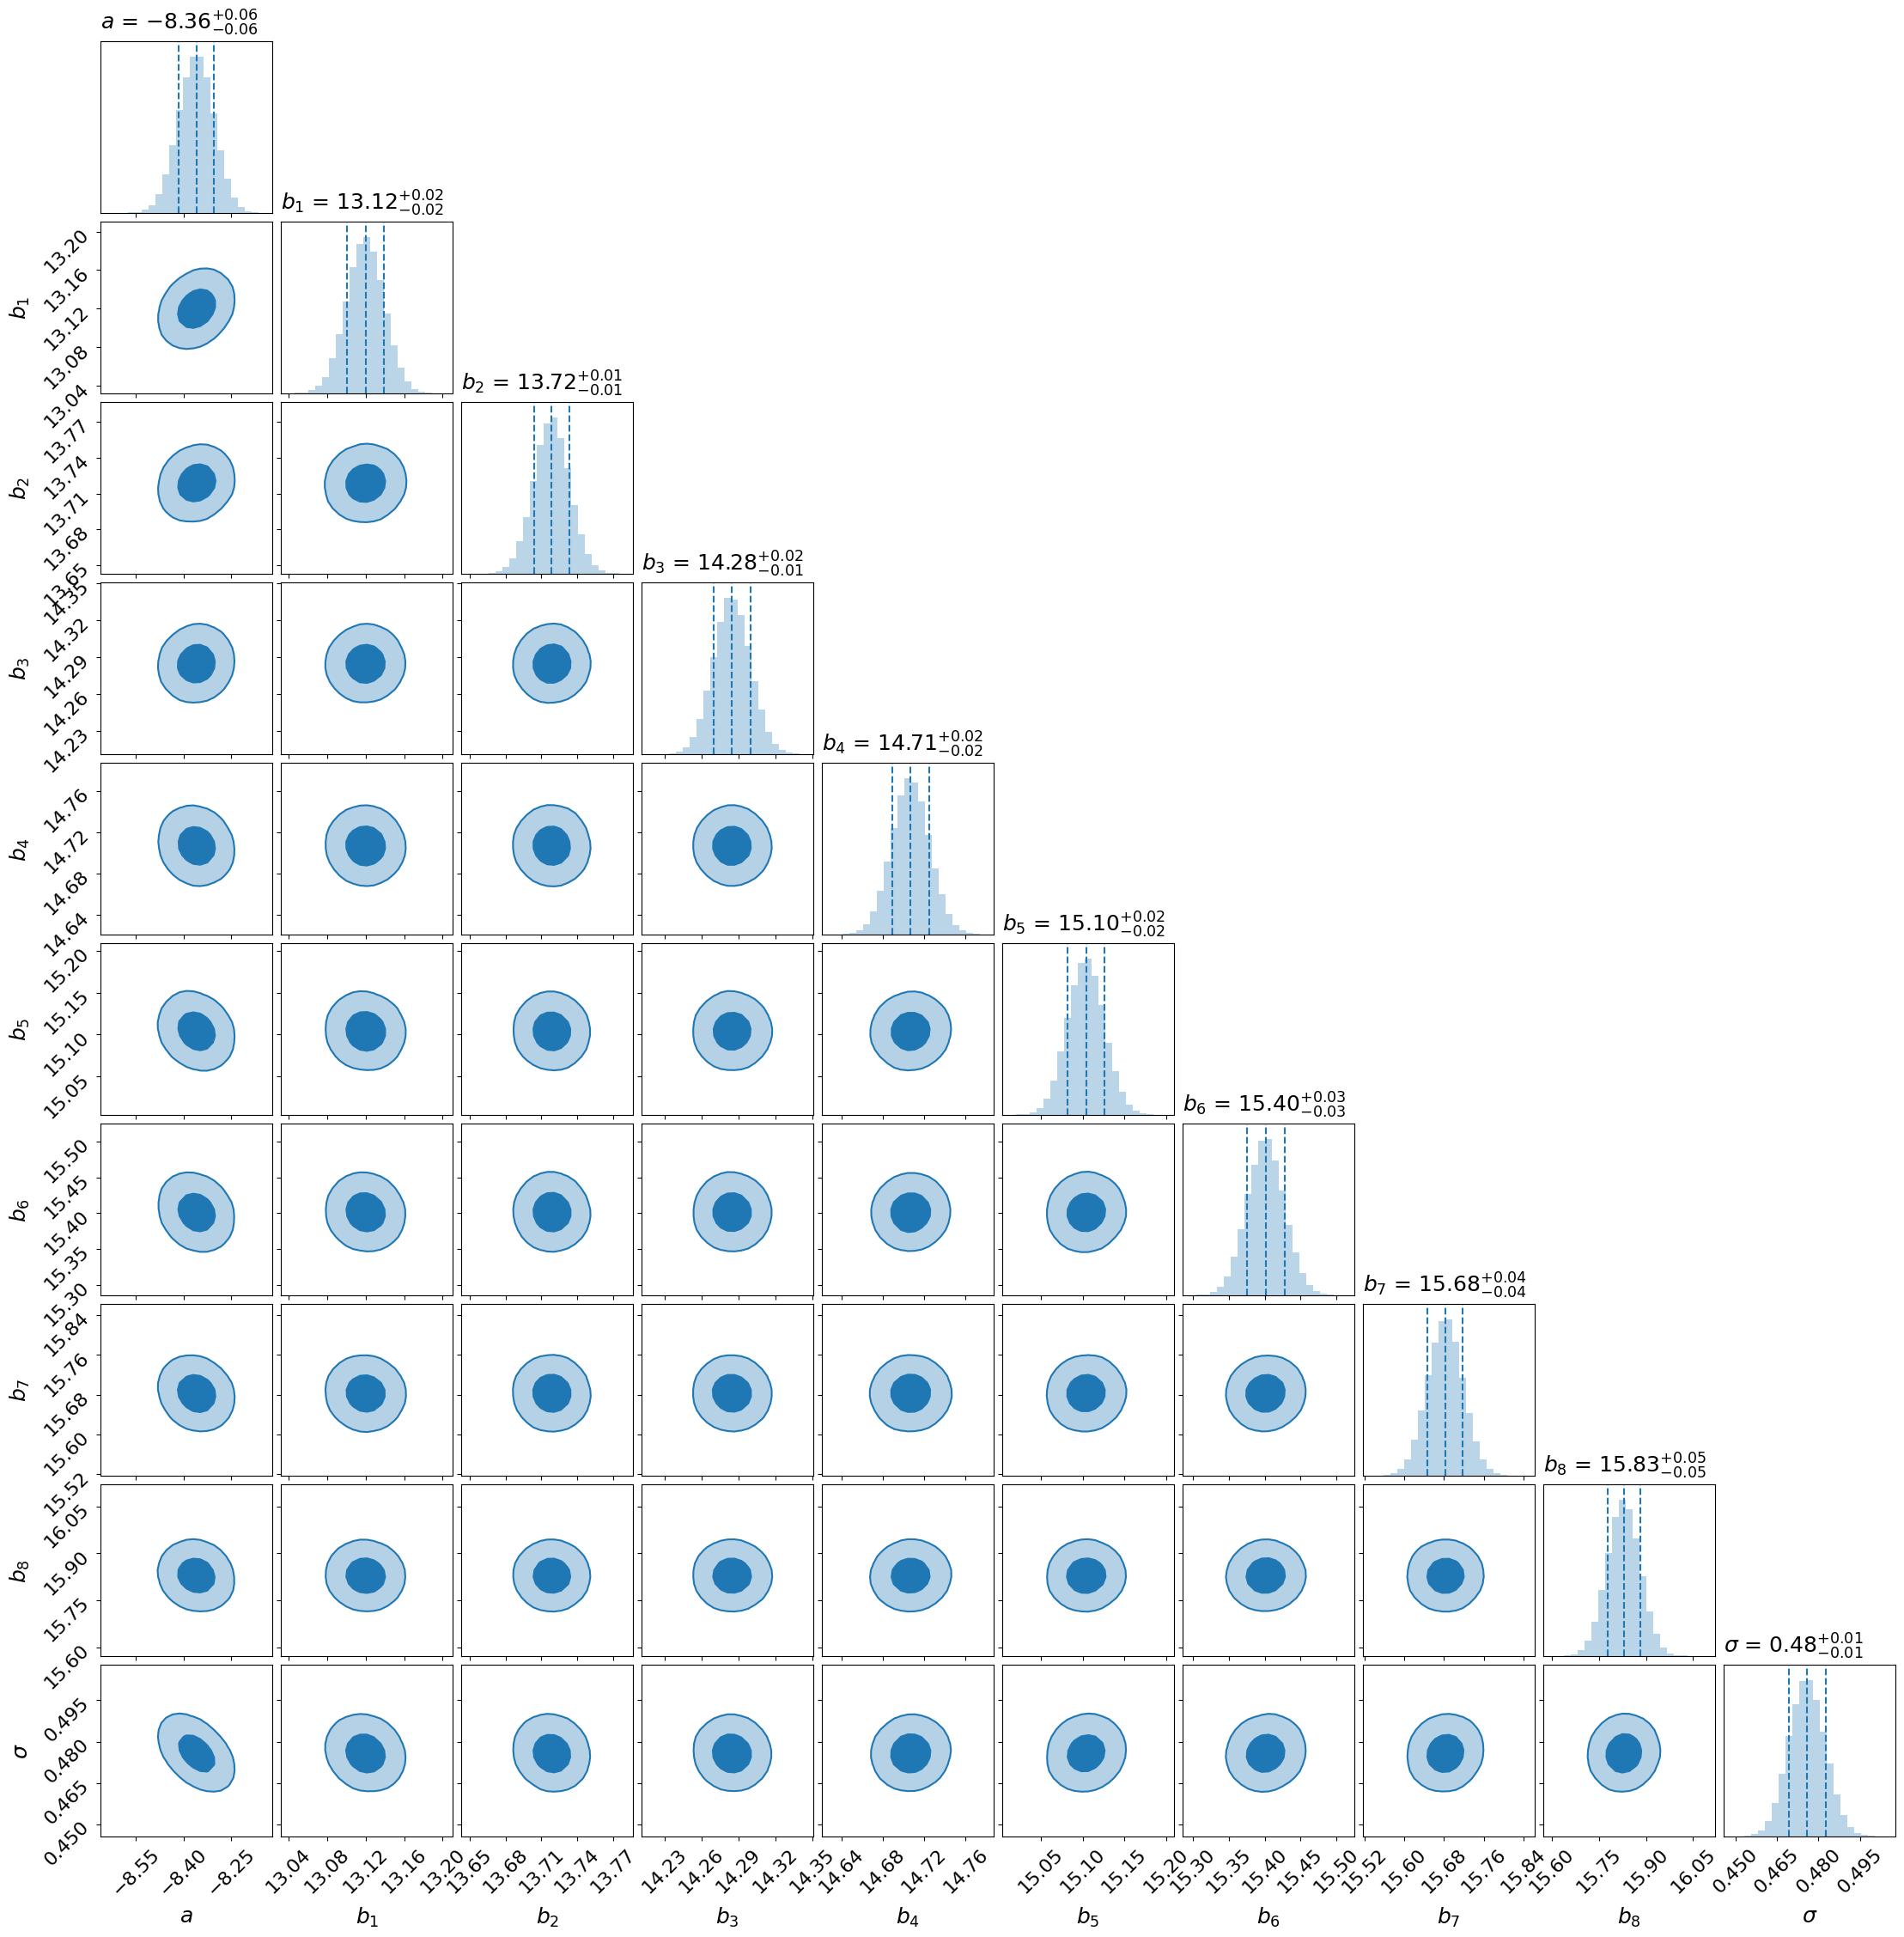

In [24]:
labels  = ['$a$']
labels += [f'$b_{{ {k+1} }}$' for k in np.arange(m)]
labels += [r'$\sigma$'] #+ [rf'$\sigma_{k}$' for k in np.arange(m)]

fig = corner(tfr_mcmc_samples.T, bins=25, smooth=1,
#              range=[[1.9, 2.4], [0.75, 1.1], [0.1, 0.3]],   # Range for a, b, sigma. Adjust as needed.
             labels=labels,
             label_kwargs={'fontsize':18},
             labelpad=0.1,
             levels=(1-np.exp(-0.5), 1-np.exp(-2)),
             quantiles=[0.16, 0.5, 0.84],
             color='tab:blue',
             hist_kwargs={'histtype':'stepfilled', 'alpha':0.3},
             plot_datapoints=False,
             fill_contours=True,
             show_titles=True,
             title_kwargs={"fontsize": 18, 'loc':'left', 'pad':10});

for ax in fig.get_axes():
    ax.tick_params(axis='both', which='major', labelsize=16)

# fig.savefig('/pscratch/sd/s/sgmoore1/TF/figures/DR2_cornerplot_v3.png',
#     dpi=150,
#     bbox_inches='tight',
#     pad_inches=0.2,
#     facecolor='none'
# )

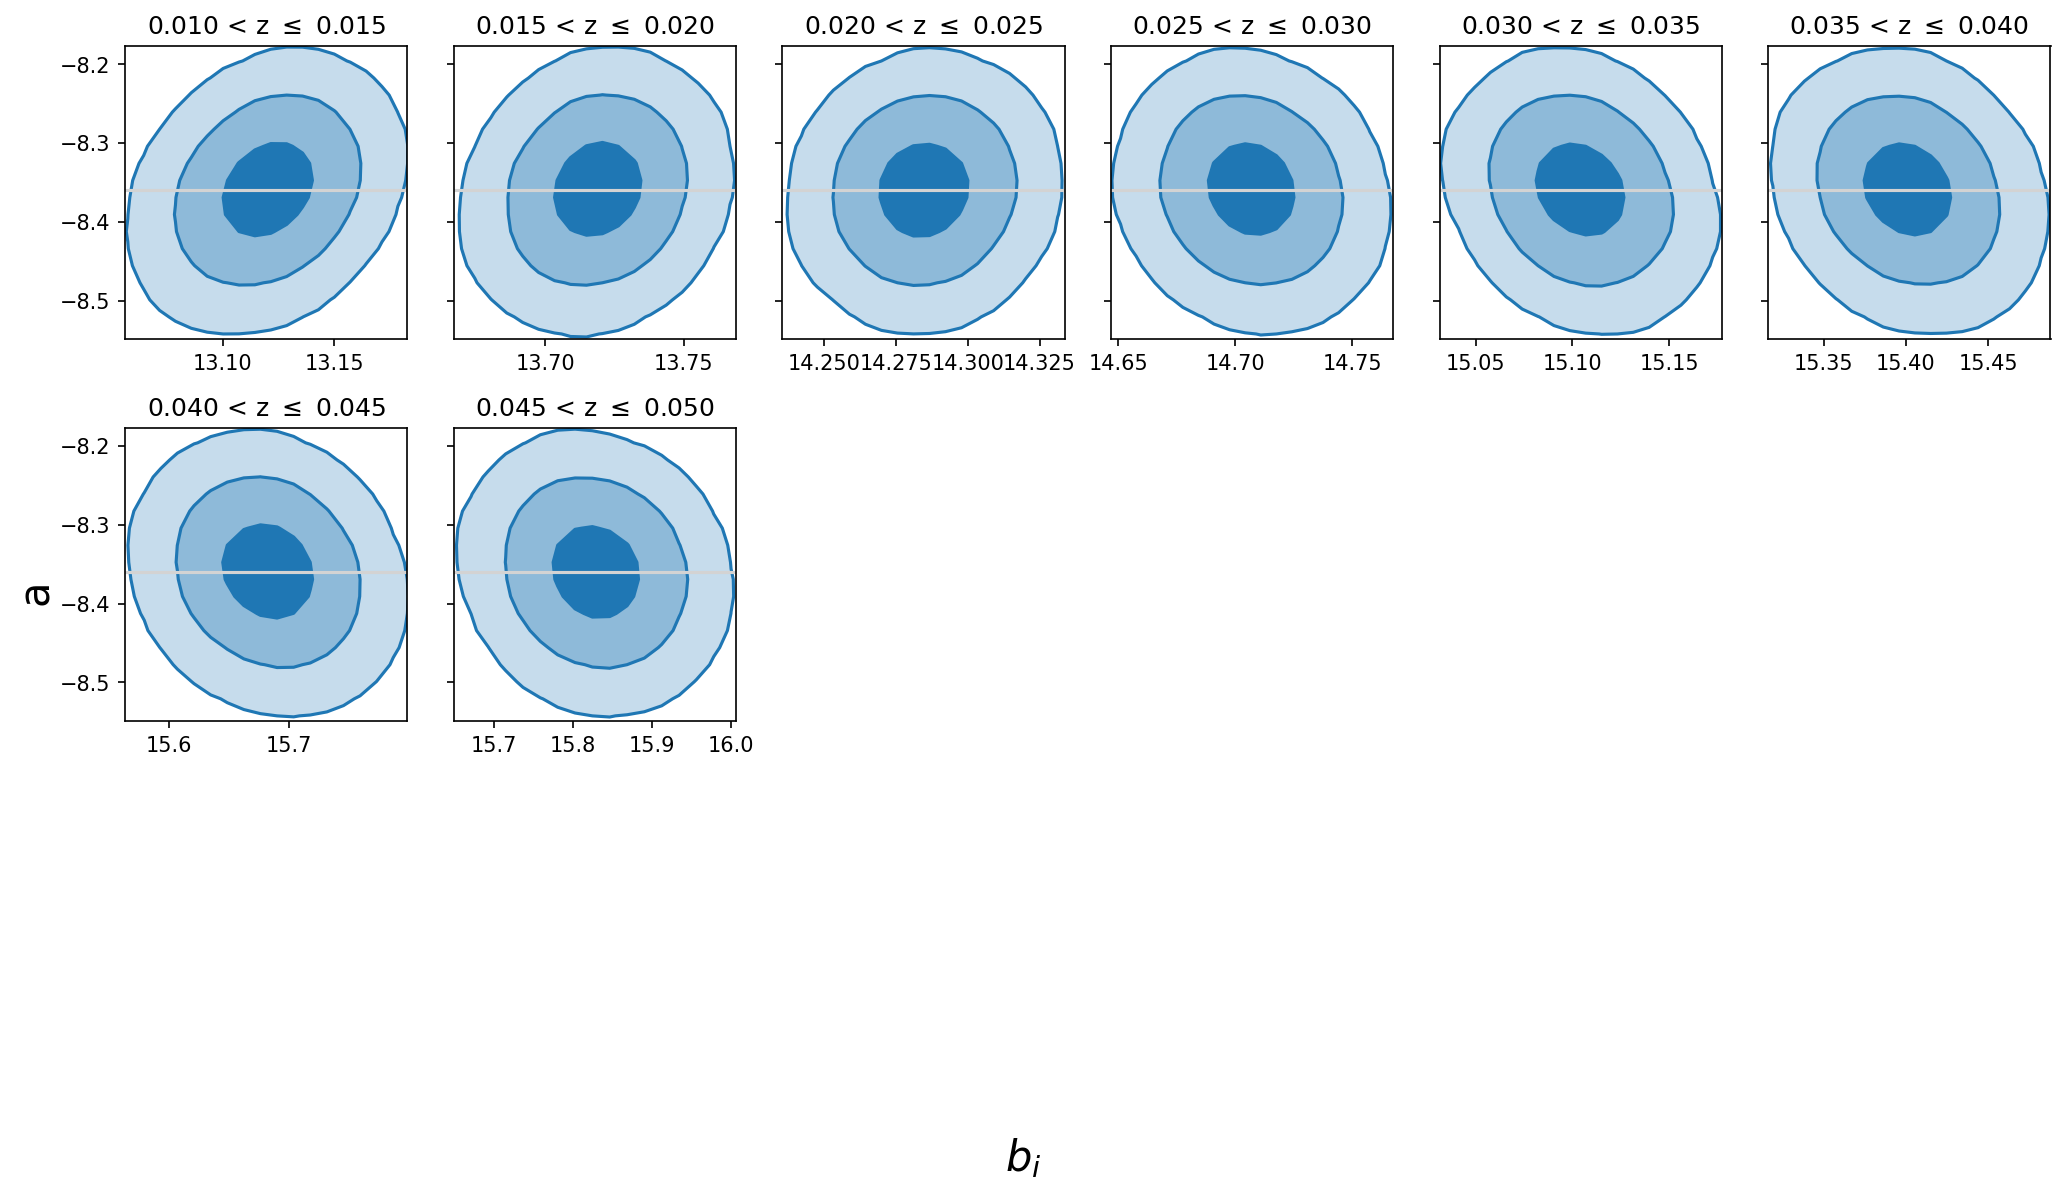

In [25]:
samples = tfr_mcmc_samples.T
a = samples[:, 0]
b_vals = samples[:, 1:-1]
n_b = b_vals.shape[1]
ncols = 6
nrows = 3
fig, axs = plt.subplots(nrows=3, ncols=ncols, sharex=False, sharey=True, figsize=(14,8), tight_layout=True,
                        facecolor='none', dpi=150)

axs = np.array(axs).reshape(-1)

for i in range(n_b):
    ax = axs[i]

    hist2d(
        b_vals[:, i],
        a,
        ax=ax,
        bins=25,
        smooth=1,
        levels=(1-np.exp(-0.5), 1-np.exp(-2), 1-np.exp(-4.5)),
        plot_datapoints=False,
        fill_contours=True,
        color='tab:blue'
    )
    ax.axhline(np.median(a), color='lightgray')

    ax.set(
        xlim = np.percentile(b_vals[:, i], [0.05,99.95]),
        ylim = np.percentile(a, [0.05,99.95]),
        title=f'{zbins[i]:.3f} < z $\\leq$ {(zbins[i+1] if i+2 < len(zbins) else zmax):.3f}'
    )

    # if i % ncols == 0:
    #     ax.set_ylabel(f'$b_{{{i+1}}}$', fontsize=14)
    # if i >= (nrows-1)*ncols:
    #     ax.set_xlabel('$a$', fontsize=14)


# turn off unused axes
for j in range(n_b, len(axs)):
    axs[j].axis('off')

fig.supxlabel(r'$b_i$', fontsize=20)
fig.supylabel('a', fontsize=20)

plt.tight_layout()
# plt.show()

# plt.savefig('/pscratch/sd/s/sgmoore1/TF/figures/Y3_v2_fit_contours.png', 
#             dpi=150, 
#             facecolor='none')


### Plot the HyperFit Results

In [26]:
sigma_mcmc = np.percentile(tfr_mcmc_samples[-1], [16., 50., 84.])
a_mcmc = np.percentile(tfr_mcmc_samples[0], [16., 50., 84])
b_mcmc = []
# for k in range(1, m+2):
for k in range(1, m+1):
    b_mcmc.append(np.percentile(tfr_mcmc_samples[k], [16., 50., 84.]))
b_mcmc = np.asarray(b_mcmc)

In [27]:
i=0
while i < 10:
    print(f'{np.mean(tfr_mcmc_samples[i]):.4f}, {np.sqrt(cov_tfr[i,i]):.4f}')
    i+=1

-8.3602, 0.0559
13.1199, 0.0194
13.7187, 0.0150
14.2848, 0.0149
14.7069, 0.0183
15.1042, 0.0220
15.4015, 0.0261
15.6828, 0.0355
15.8287, 0.0528
0.4760, 0.0066


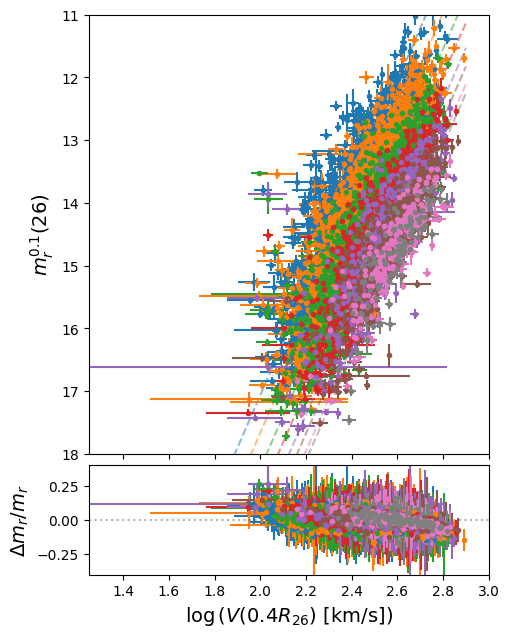

In [28]:
# fig, axes = plt.subplots(2,2, figsize=(10,7), sharex=True,
fig, axes = plt.subplots(2,1, figsize=(5,7), sharex=True,
                         gridspec_kw={'height_ratios':[4,1], 'hspace':0.04, 'wspace':0.25})

a_   = a_mcmc[1]
# b0pt = b_mcmc[0,1]
b_   = b_mcmc[:,1]#[1:]

#- Plot redshift bins
# ax = axes[0,0]
ax = axes[0]

plt.rcParams['axes.prop_cycle'] = plt.cycler('color', plt.cm.viridis(np.linspace(0,1,m)))

_logv = np.arange(0, 3, 0.1) - logV0
for k in range(m):
    eb = ax.errorbar(x=logV0 + logV[k],#+1], 
                     y=mag[k],#+1], 
                     xerr=logV_err[k],#+1], 
                     yerr=mag_err[k],#+1],
                     fmt='.', 
                     label=f'{zbins[k]:.3f}-{zbins[k+1]:.3f}')

    ax.plot(_logv + logV0, a_*_logv + b_[k], color=eb[0].get_color(), ls='--', alpha=0.5)

ax.set(xlim=[1.25, 3],
       ylim=[18, 11])
ax.set_ylabel(r'$m_r^{0.1} (26)$', fontsize=14)
# ax.legend(loc='upper left', fontsize=9, ncol=2);
'''
#- Plot calibrators
ax = axes[0,1]
eb = ax.errorbar(x=logV[0] + logV0, y=mag[0], xerr=logV_err[0], yerr=mag_err[0],
                 fmt='.', color='tab:blue', label=f'0-pt')

ax.plot(_logv + logV0, a_*_logv + b0pt, color=eb[0].get_color(), ls='--')#, label='fit')
ax.set(xlim=[1.25, 2.6],
       ylim=[-18, -24]
      )
ax.set_ylabel(r'$M_r^{0.1}(26) = m_r^{0.1}(26) - \mu$', fontsize=14)
ax.legend(loc='upper left', fontsize=9, ncol=2)
'''
#- Plot residuals: z-bins
# ax = axes[1,0]
ax = axes[1]

plt.rcParams['axes.prop_cycle'] = plt.cycler('color', plt.cm.viridis(np.linspace(0,1,m)))

for k in range(m):
    logv_obs = logV[k]#+1]
    m_obs = mag[k]#+1]
    m_exp = (a_*logv_obs + b_[k])
    eb = ax.errorbar(x=logv_obs + logV0, y=(m_exp-m_obs)/m_exp, 
                     xerr=logV_err[k],#+1], 
                     yerr=mag_err[k],#+1],
                     fmt='.')

ax.axhline(0, ls=':', color='k', alpha=0.3)

ax.set(xlim=[1.25, 3],
       ylim=[-0.4, 0.4])
ax.set_xlabel(r'$\log{(V(0.4R_{26})~[\mathrm{km/s}]}$)', fontsize=14)
ax.set_ylabel(r'$\Delta m_r/m_r$', fontsize=14)
'''
#- Plot residuals: calibrators
ax = axes[1,1]

logv_obs = logV[0]
m_obs = mag[0]
m_exp = (a_*logv_obs + b0pt)

b = ax.errorbar(x=logv_obs + logV0, y=(m_exp-m_obs)/m_exp, 
                xerr=logV_err[0], yerr=mag_err[0],
                fmt='.', color='tab:blue')
ax.axhline(0, ls=':', color='k', alpha=0.3)

ax.set(xlim=[1.25, 2.6],
       ylim=[-0.4, 0.4])
ax.set_xlabel(r'$\log{(V(0.4R_{26})~[\mathrm{km/s}]}$)', fontsize=14)
ax.set_ylabel(r'$\Delta M_r/M_r$', fontsize=14)
'''
fig.subplots_adjust(left=0.1, bottom=0.1, top=0.9, right=0.9);

# fig.savefig('../../Figures/Y1/TF_Y1_cluster_calibration_0pt_binaryMLupdated_z0p1_Anthony2_weightsVmax-1_dVsys_fit0_20250717.png', 
#             dpi=150, 
#             facecolor='none')

In [29]:
print(f'slope (alpha): {-a_/2.5:.2f} +/- {np.sqrt(cov_tfr[0,0])/2.5:.3f}')

slope (alpha): 3.34 +/- 0.022


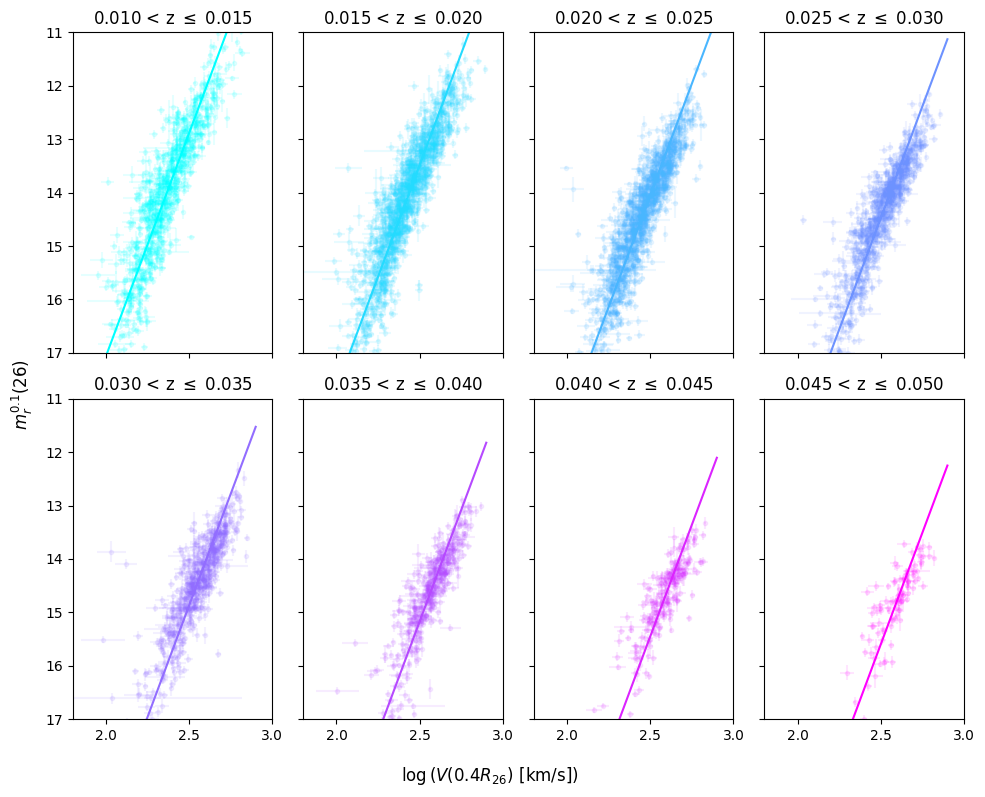

In [30]:
# fig, axs = plt.subplots(nrows=7, ncols=10, sharex=True, sharey=True, figsize=(20,16), tight_layout=True)
fig, axs = plt.subplots(nrows=2, ncols=4, sharex=True, sharey=True, figsize=(10,8), tight_layout=True)

color = iter(plt.cm.cool(np.linspace(0,1,m)))
for i in range(m):
    c = next(color)
    
    row = int(i/4)
    col = i%4
    
    eb = axs[row,col].errorbar(logV0 + logV[i],#+1], 
                               mag[i],#+1], 
                               xerr=logV_err[i],#+1], 
                               yerr=mag_err[i],#+1], 
                               fmt='.', color=c, alpha=0.1)
    axs[row,col].plot(_logv + logV0, a_*_logv + b_[i], color=c)
    
    axs[row,col].set(xlim=[1.8, 3], ylim=[17, 11], title=f'{zbins[i]:.3f} < z $\leq$ {zbins[i+1]:.3f}')

# Delete extra axes
# fig.delaxes(axs[-1,-1])

fig.supxlabel(r'$\log{(V(0.4R_{26})~[\mathrm{km/s}]}$)')
fig.supylabel(r'$m_r^{0.1} (26)$');

# plt.savefig('../../Figures/Y1/TF_Y1_individual_cluster_calibration_0pt_binaryMLupdated_z0p1_Anthony2_weightsVmax-1_dVsys_fit0_20250717.png', 
#             dpi=150, 
#             facecolor='none')

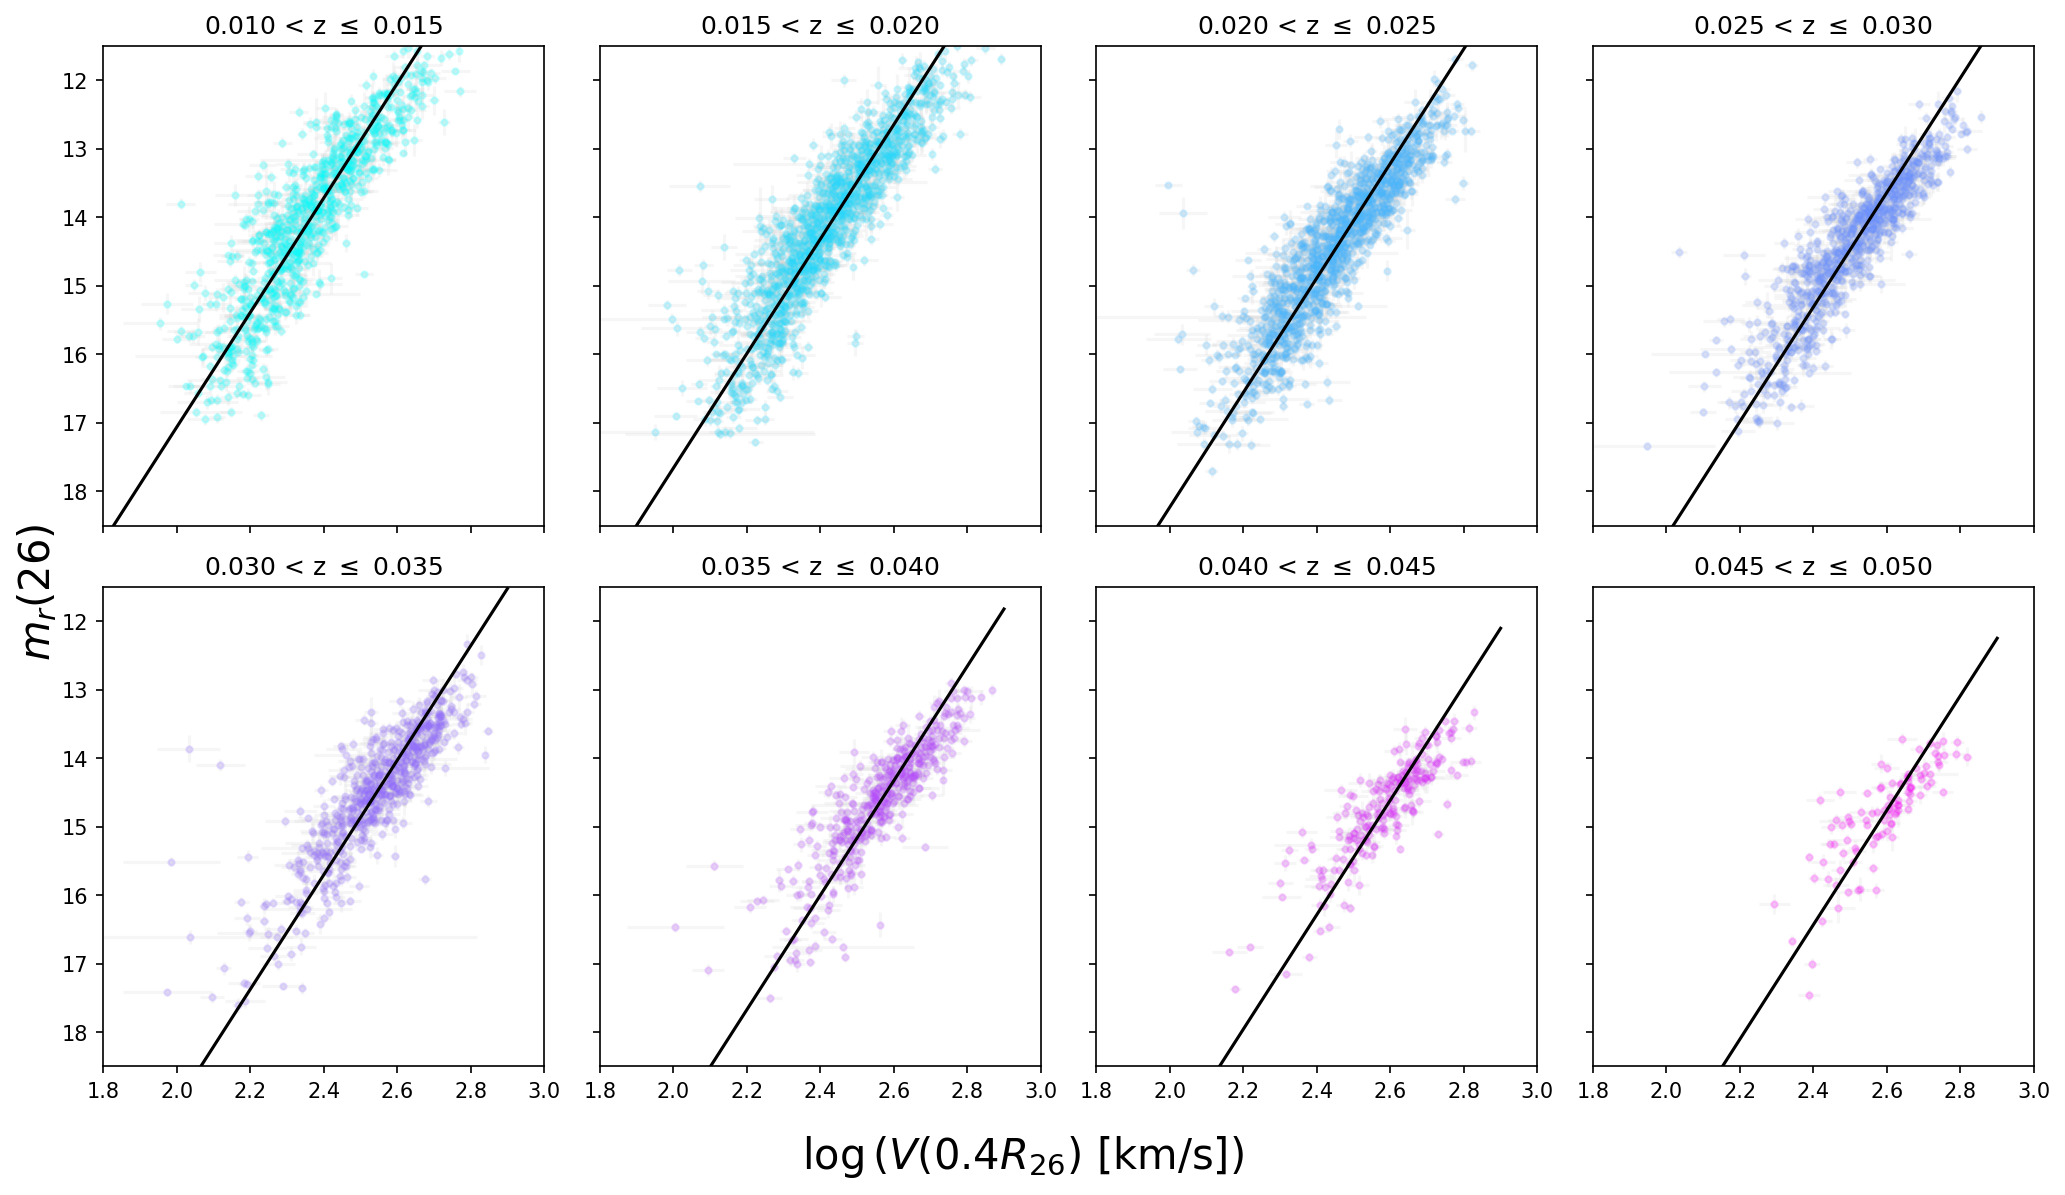

In [31]:
zbin_indices = np.digitize(cf4['Z_CMB'], zbins, right=True)

ncols=4
fig, axs = plt.subplots(nrows=2, ncols=ncols, sharex=True, sharey=True, figsize=(14,8), tight_layout=True,
                        facecolor='none', dpi=150)
# fig, axs = plt.subplots(nrows=3, ncols=5, sharex=True, sharey=True, figsize=(10,8), tight_layout=True)
m = len(zbins)-1
color = iter(plt.cm.cool(np.linspace(0,1,m)))
for i in range(m):
    c = next(color)
    
    row = int(i/ncols)
    col = i%ncols
    
    eb = axs[row,col].errorbar(cf4['logWmxi'][(zbin_indices==i+1)&cf4['MAIN']],#+1], 
                               cf4['R_MAG_CORR'][(zbin_indices==i+1)&cf4['MAIN']],#+1], 
                               xerr=cf4['e_logWmxi'][(zbin_indices==i+1)&cf4['MAIN']],#+1], 
                               yerr=cf4['R_MAG_ERR_CORR'][(zbin_indices==i+1)&cf4['MAIN']],#+1], 
                               fmt='.', color=c, ecolor='lightgray', alpha=0.2)
    # axs[row,col].plot(_logv + logV0, a_*_logv + b_[i], color=c)
    # plot_ellipse(mean=(mu_x[i], mu_y[i]), cov = ([cov_xx[i], cov_xy[i]],[cov_yx[i], cov_yy[i]]),
    #              n_std = sigma, ax=axs[row,col], edgecolor='k', facecolor='none', zorder=6)

    
    # axs[row,col].set(xlim=[1.5, 2.6], ylim=[18, 13], title=f'{zbins[i]:.3f} < z $\leq$ {(zbins[i+1] if i+2 < len(zbins) else zmax):.3f}')
    axs[row,col].plot(_logv + logV0, a_*_logv + b_[i], color='k', zorder=6)
    axs[row,col].set(xlim=[1.8, 3], ylim=[18.5, 11.5], title=f'{zbins[i]:.3f} < z $\leq$ {(zbins[i+1] if i+2 < len(zbins) else zmax):.3f}')

# Delete extra axes
# fig.delaxes(axs[-1,-1])

fig.supxlabel(r'$\log{(V(0.4R_{26})~[\mathrm{km/s}]}$)', fontsize=20)
fig.supylabel(r'$m_r (26)$', fontsize=20);

# plt.savefig('/pscratch/sd/s/sgmoore1/TF/figures/DR2_v3_bin_ellipses_postfit.png', 
#             dpi=150, 
#             facecolor='none')


In [32]:
for i in range(m):

    # Number of galaxies in this bin
    N_gal = len(mag[i])

    # Calculate expected magnitude given the measured V
    mag_TF = a_*logV[i] + b_[i]

    # Calculate difference between the predicted and measured magnitude
    mag_diff = mag[i] - mag_TF

    # plt.figure(tight_layout=True)
    # plt.hist(mag_diff, bins=30)
    # break

    # Calculate rms
    rms_scatter = np.sqrt(np.sum(mag_diff**2)/N_gal)
    
    print(f'{i:2d}  {zbins[i]:0.3f} < z <= {zbins[i+1]:0.3f}, {N_gal}  {rms_scatter:.2f} mag')

 0  0.010 < z <= 0.015, 822  0.60 mag
 1  0.015 < z <= 0.020, 1266  0.57 mag
 2  0.020 < z <= 0.025, 1280  0.56 mag
 3  0.025 < z <= 0.030, 844  0.52 mag
 4  0.030 < z <= 0.035, 622  0.60 mag
 5  0.035 < z <= 0.040, 425  0.53 mag
 6  0.040 < z <= 0.045, 221  0.51 mag
 7  0.045 < z <= 0.050, 101  0.52 mag


# Calculate logdistance ratios

In [33]:
cosmo = FlatLambdaCDM(H0=H0, Om0=0.3151)
# cosmo = DESI()

cf4['MU_ZCMB'] = cosmo.distmod(cf4['Z_CMB'].value)

cf4['R_ABSMAG'] = cf4['R_MAG_CORR'] - cf4['MU_ZCMB'].value

In [34]:
##### We don't have any way of getting redshift uncertainties from CF4
# rng = np.random.default_rng()

# N_samples = 1000

# mu_err = np.empty(len(cf4['MU_ZCMB']))*u.mag

# for i in tqdm(range(len(mu_err))):
    
#     z_desi_random = rng.normal(np.abs(cf4['Z_CMB'][i]), 
#                                cf4['ZERR_DESI'][i], 
#                                N_samples)
    
#     mu_random = cosmo.distmod(z_desi_random)
    
#     mu_err[i] = np.std(mu_random)

# cf4['MU_ZCMB_ERR'] = mu_err

cf4['R_ABSMAG_ERR'] = np.sqrt(cf4['R_MAG_ERR_CORR']**2) #+ cf4['MU_ZCMB_ERR'].value**2)

In [35]:
# Center redshift values of each bin
zmin = 0.01
zmax = 0.05
dz = 0.005
zbins = np.arange(zmin, zmax+dz/2, dz)
zc = 0.5*dz + zbins[:-1]

# Distance modulus for each redshift bin center
mu_zc = cosmo.distmod(zc)

In [36]:
slopes = tfr_mcmc_samples[0]
slope = np.median(tfr_mcmc_samples[0])
slope_err = np.sqrt(cov_tfr[0,0])

# Each redshift bin has its own 0pt
# To put it in absolute-magnitude space, we'll convert it to an absolute magnitude using the middle of the redshift bin
ZPs = tfr_mcmc_samples[1:-1] - mu_zc[:,None].value
ZP = np.median(tfr_mcmc_samples[1:-1], axis=1) - mu_zc.value
ZP_err = np.sqrt(np.diagonal(cov_tfr[1:-1,1:-1])) # Should include z-bin width to this uncertainty

sig = np.median(tfr_mcmc_samples[-1])

logv = np.linspace(-1*np.ones(len(zbins)-1), 3.5*np.ones(len(zbins)-1), 100)
absmag = slope*(logv - logV0) + ZP

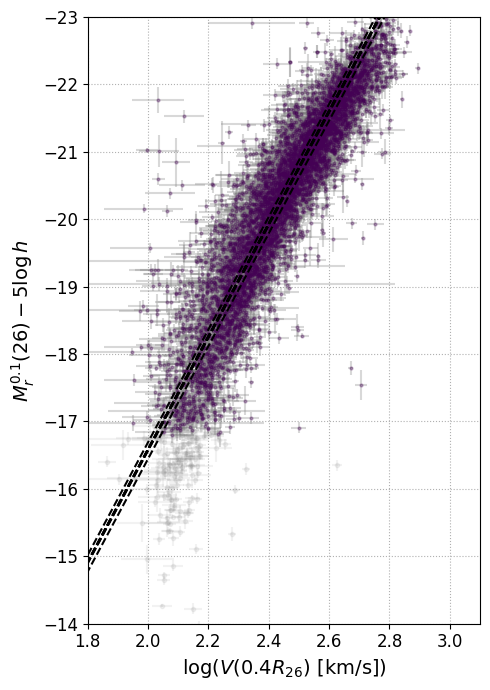

In [37]:
plt.figure(figsize=(5,7), tight_layout=True)

plt.grid(ls=':')

# plt.fill_between(logv, line_err[0], line_err[1], color='lightgray')

sample = outlier_boolean# & morph_boolean
plt.errorbar(cf4['logWmxi'][sample], 
             cf4['R_ABSMAG'][sample], 
             xerr=cf4['e_logWmxi'][sample],
             yerr=cf4['R_ABSMAG_ERR'][sample], 
             fmt='.',
             color='gray',
             alpha=0.1, 
             ecolor='gray')

sample = ~outlier_boolean# & morph_boolean
plt.errorbar(cf4['logWmxi'][sample], 
             cf4['R_ABSMAG'][sample], 
             xerr=cf4['e_logWmxi'][sample],
             yerr=cf4['R_ABSMAG_ERR'][sample], 
             fmt='.', 
             markersize=4, 
             alpha=0.3, 
             ecolor='gray')

# sample = ~outlier_boolean_alt & outlier_boolean
# plt.errorbar(cf4['logWmxi'][sample], 
#              cf4['R_ABSMAG'][sample], 
#              xerr=cf4['e_logWmxi'][sample],
#              yerr=cf4['R_ABSMAG_ERR'][sample], 
#              fmt='.', 
#              markersize=4, 
#              alpha=0.2, 
#              ecolor='gray')



plt.plot(logv, absmag, 'k--', zorder=3)

plt.xlim([1.8, 3.1])
plt.ylim([-14, -23])

plt.xlabel('log($V(0.4R_{26})$ [km/s])', fontsize=14)
plt.ylabel('$M_r^{0.1} (26) - 5\log h$', fontsize=14);

ax = plt.gca()
ax.tick_params(axis='both', which='major', labelsize=12);

# plt.savefig('../../Figures/Y1/iron_jointTFR_varyV0-perpdwarf_z0p1_Anthony2_weightsVmax-1_dVsys_20250717.png', 
#             dpi=150, 
#             facecolor='none')

Text(0, 0.5, '$M_r(26)$')

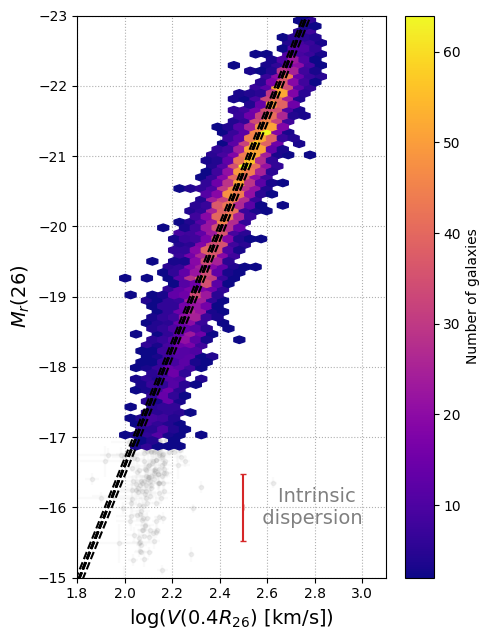

In [38]:
plt.figure(figsize=(5,6.5), tight_layout=True)
plt.grid(ls=':')

plt.errorbar(cf4['logWmxi'][outlier_boolean], 
             cf4['R_ABSMAG'][outlier_boolean], 
             xerr=cf4['e_logWmxi'][outlier_boolean],
             yerr=cf4['R_ABSMAG_ERR'][outlier_boolean], 
             fmt='.',
             color='gray',
             alpha=0.1, 
             ecolor='lightgray', zorder=1)

plt.hexbin(cf4['logWmxi'][~outlier_boolean], 
           cf4['R_ABSMAG'][~outlier_boolean], 
           cmap='plasma', 
           mincnt=2, 
           gridsize=(70,80), 
           extent=(-0.1, 3.1, -25, -12.25), zorder=2)
plt.colorbar(label='Number of galaxies')

# plt.fill_between(logv, line_err[0], line_err[1], color='lightgray', alpha=0.2)
plt.plot(logv, absmag, 'k--', zorder=3)


plt.errorbar([2.5], [-16], 
             xerr=0,
             yerr=sig, 
             ecolor='tab:red', 
             capsize=2)
plt.annotate('Intrinsic \n dispersion', 
             (3, -16), 
             va='center',
             ha='right',
             c='gray',
             fontsize=14)

plt.xlim([1.8, 3.1])
plt.ylim([-15, -23])

plt.xlabel('log($V(0.4R_{26})$ [km/s])', fontsize=14)
plt.ylabel('$M_r(26)$', fontsize=14)

# plt.savefig('/pscratch/sd/s/sgmoore1/TF/figures/Y3_tfr_hexbin_hyperfit_v3.png', 
#             dpi=150, 
#             facecolor='none')

#### Redshift distribution

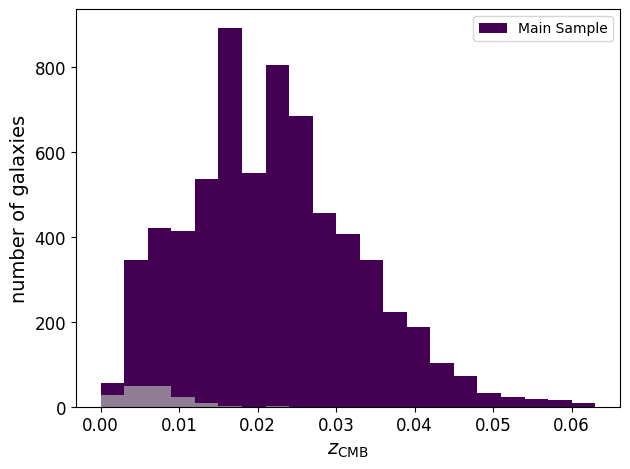

In [39]:
plt.figure(tight_layout=True)

plt.hist(cf4['Z_CMB'][~outlier_boolean],
         bins=np.arange(0, 0.065, 0.003), label='Main Sample')
plt.hist(cf4['Z_CMB'][outlier_boolean],
         bins=np.arange(0, 0.065, 0.003), 
         color='darkgray',
         alpha=0.75, label='')

plt.tick_params(axis='both', which='major', labelsize=12)

plt.xlabel(r'$z_{\text{CMB}}$', fontsize=14)
plt.ylabel('number of galaxies', fontsize=14)
plt.legend()
# plt.savefig('/pscratch/sd/s/sgmoore1/TF/figures/DR2_v3_histogram_z.png', 
#             dpi=150, 
#             facecolor='none')

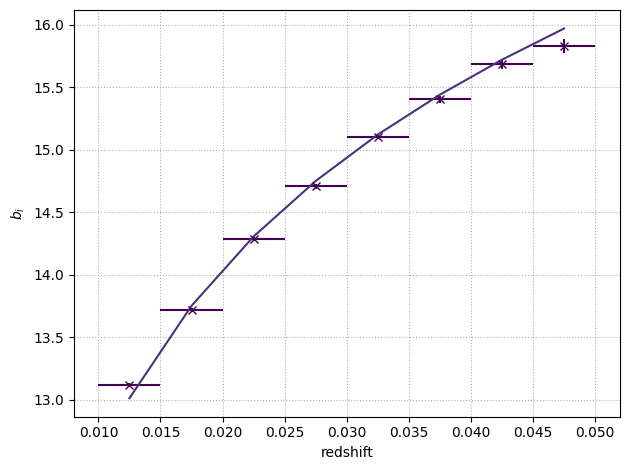

In [40]:
plt.figure(tight_layout=True)

plt.grid(ls=':')

plt.errorbar(zc, np.median(tfr_mcmc_samples[1:-1], axis=1), 
             xerr=0.5*dz, 
             yerr=ZP_err, 
             fmt='x')

plt.plot(zc, mu_zc-20.5*u.mag, label=r'$\mu (\Omega_{m,0}=0.3151, h=1) - 20.5$')

# plt.xlim(0.028, 0.102)
# plt.ylim(-20.5, -20.7)

plt.xlabel('redshift')
plt.ylabel('$b_i$');

# Distance moduli

In [41]:
# First, match each galaxy to its redshift bin
zbin_indices = np.digitize(cf4['Z_CMB'], zbins, right=True)

# For those galaxies that fall outside the calibration range, assign them to the closest bin
zbin_indices[zbin_indices == 0] = 1
zbin_indices[zbin_indices == len(zbins)] = len(zbins) - 1

# Then, use that galaxy's redshift bin's zero-point to calculate the distance modulus
cf4['R_ABSMAG_TF'] = np.nan
for i in range(len(cf4)):
    cf4['R_ABSMAG_TF'][i] = slope*(cf4['logWmxi'][i] - logV0) + ZP[zbin_indices[i] - 1]

In [42]:
cf4['R_ABSMAG_TF_ERR'] = np.nan
cf4['R_ABSMAG_TF_ERR_STAT'] = np.nan

rng = np.random.default_rng()

for i in tqdm(range(len(cf4))):
    
    v_random = rng.normal(10**cf4['logWmxi'][i], 
                          10**cf4['logWmxi'][i]*cf4['e_logWmxi'][i]/0.434, 
                          # size=10000)
                          size=len(slopes))
    v_random_good = v_random[v_random > 0]

    ############################################################################
    # Statistical uncertainty
    #---------------------------------------------------------------------------
    Ms_stat = slope*(np.log10(v_random_good) - logV0) + ZP[zbin_indices[i] - 1]

    cf4['R_ABSMAG_TF_ERR_STAT'][i] = np.nanstd(Ms_stat)
    ############################################################################

    
    ############################################################################
    # Total uncertainty
    #---------------------------------------------------------------------------
    Ms = slopes[v_random > 0]*(np.log10(v_random_good) - logV0) + ZPs[zbin_indices[i] - 1,v_random > 0]
    
    cf4['R_ABSMAG_TF_ERR'][i] = np.sqrt(np.nanstd(Ms)**2 + sig**2)
    ############################################################################
    

################################################################################
# Systematic uncertainty
#-------------------------------------------------------------------------------
cf4['R_ABSMAG_TF_ERR_SYS'] = np.sqrt(cf4['R_ABSMAG_TF_ERR']**2 - cf4['R_ABSMAG_TF_ERR_STAT']**2)
################################################################################

100%|██████████| 6769/6769 [04:01<00:00, 28.00it/s]


In [43]:
def profile_histogram(x, y, xbins, yerr=None, weights=None, median=False, weighted=False):
    """Compute a profile histogram from scattered data.
    
    Parameters
    ----------
    x : list or ndarray
        Ordinates (independent variable).
    y : list or ndarray
        Coordinates (dependent variable).
    xbins : list or ndarray
        Bin edges for the independent variable.
    yerr : list or ndarray
        Uncertainties on the dependent variable. Assumed independent.
    weights : list or ndarray
        If not None (and weighted=True), will use this instead of yerr to weight 
        the summary statistics.
    median : bool
        If true, compute median as central value; else, the (weighted) mean.
    weighted : bool
        Weight the summary statistics, either by the uncertainty in y or the 
        provided weights.
        
    Returns
    -------
    N : ndarray
        Unweighted counts per bin.
    h : ndarray
        Summary statistic (mean or median) of independent variable per bin.
    e : ndarray
        Uncertainty on the summary statistic per bin.
    """
    
    N = binned_statistic(x, y, bins=xbins, statistic='count').statistic

    if weighted:
        if (yerr is None) and (weights is None):
            raise ValueError('need to define either yerr or weights if using weighted fit.')

        if weights is None:
            # weight based on yerr
            w = 1/yerr**2
        else:
            w = weights
        W, H, E = binned_statistic(x, [w, w*y, w*y**2], bins=xbins, statistic='sum').statistic
        h = H/W
        e = 1/np.sqrt(W)
    else:
        mean, mean2 = binned_statistic(x, [y, y**2], bins=xbins, statistic='mean').statistic
        h = mean
        e = np.sqrt((mean2 - mean**2) / (N - 1))

    if median:
        h = binned_statistic(x, y, bins=xbins, statistic='median').statistic
    
    return N, h, e

/tmp/ipykernel_2003104/3818747994.py:50: RuntimeWarning: invalid value encountered in divide
  e = np.sqrt((mean2 - mean**2) / (N - 1))


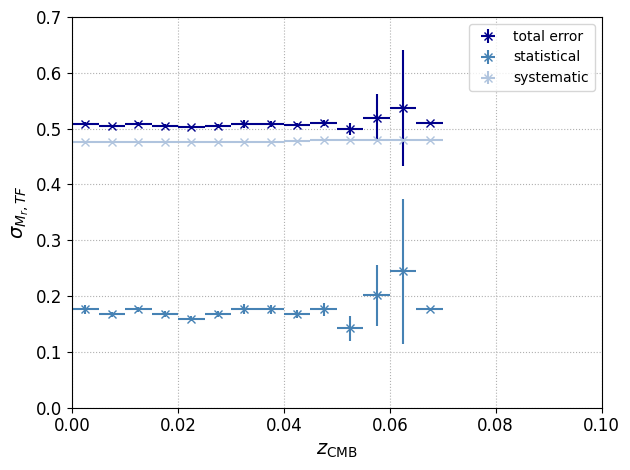

In [44]:
zbins = np.arange(0, 0.105, 0.005)
dz = 0.5*np.diff(zbins)
zc = 0.5*(zbins[1:] + zbins[:-1])

sample1 = ~outlier_boolean
sample2 = outlier_boolean

plt.figure(tight_layout=True)

# plt.plot(tf_data['Z_DESI_CMB'][sample1], tf_data['R_ABSMAG_TF_ERR'][sample1], '.', alpha=0.1)

# Total uncertainty
N, y_avg, y_std = profile_histogram(cf4['Z_CMB'][sample1], 
                                    cf4['R_ABSMAG_TF_ERR'][sample1], 
                                    zbins, 
                                    median=True)
plt.errorbar(zc, y_avg, xerr=dz, yerr=y_std, fmt='x', color='darkblue', label='total error')

# Statistical uncertainty (just from velocity uncertainty)
N, y_avg, y_std = profile_histogram(cf4['Z_CMB'][sample1], 
                                    cf4['R_ABSMAG_TF_ERR_STAT'][sample1], 
                                    zbins, 
                                    median=True)
plt.errorbar(zc, y_avg, xerr=dz, yerr=y_std, fmt='x', color='steelblue', label='statistical')

# Systematic uncertainty (from TF calibration)
N, y_avg, y_std = profile_histogram(cf4['Z_CMB'][sample1], 
                                    cf4['R_ABSMAG_TF_ERR_SYS'][sample1], 
                                    zbins, 
                                    median=True)
plt.errorbar(zc, y_avg, xerr=dz, yerr=y_std, fmt='x', color='lightsteelblue', label='systematic')

plt.grid(ls=':')

plt.legend()

plt.xlim(0, 0.1)
plt.ylim(0, 0.7)

plt.tick_params(axis='both', which='major', labelsize=12)

plt.xlabel(r'$z_{\text{CMB}}$', fontsize=14)
plt.ylabel(r'$\sigma_{M_r, TF}$', fontsize=14);

## Compute distance modulus based on our TFR

In [45]:
cf4['MU_TF'] = cf4['R_MAG_CORR'] - cf4['R_ABSMAG_TF']

cf4['MU_TF_ERR'] = np.sqrt(cf4['R_MAG_ERR_CORR']**2 + cf4['R_ABSMAG_TF_ERR']**2)

## $\Delta M_r$ v. redshift

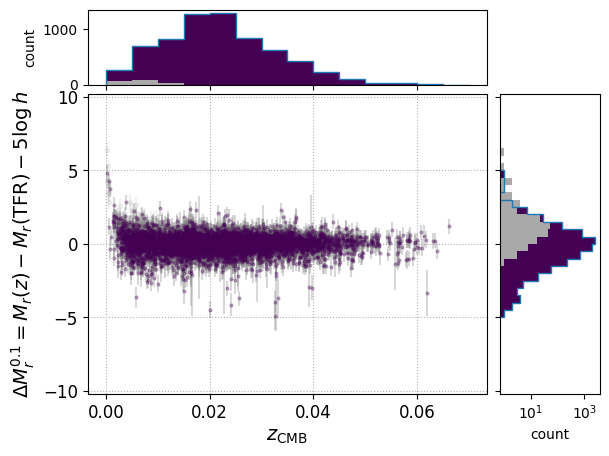

In [46]:
fig = plt.figure()

gs = fig.add_gridspec(2, 2, width_ratios=(4,1), height_ratios=(1,4), left=0.1, right=0.9, bottom=0.1, top=0.9, wspace=0.05, hspace=0.05)

ax = fig.add_subplot(gs[1,0])

sample = outlier_boolean# & morph_boolean
ax.errorbar(cf4['Z_CMB'][sample], 
             cf4['R_ABSMAG'][sample] - cf4['R_ABSMAG_TF'][sample], 
             # xerr=cf4['ZERR_DESI'][sample], 
             yerr=cf4['MU_TF_ERR'][sample],
             fmt='.', 
             color='gray',
             alpha=0.1, 
             ecolor='gray')

sample = ~outlier_boolean
ax.errorbar(cf4['Z_CMB'][sample], 
             cf4['R_ABSMAG'][sample] - cf4['R_ABSMAG_TF'][sample], 
             # xerr=cf4['ZERR_DESI'][sample], 
             yerr=cf4['MU_TF_ERR'][sample],
             fmt='.', 
             markersize=4, 
             alpha=0.3, 
             ecolor='gray')

ax.grid(ls=':')

plt.tick_params(axis='both', which='major', labelsize=12)

ax.set_xlabel(r'$z_{\text{CMB}}$', fontsize=14)
ax.set_ylabel(r'$\Delta M_r^{0.1} = M_r(z) - M_r(\text{TFR}) - 5\log h$', fontsize=14)

ax.set_ylim((-10.2, 10.2))


ax_histx = fig.add_subplot(gs[0,0], sharex=ax)
ax_histx.hist(cf4['Z_CMB'][~outlier_boolean],
              bins=np.arange(0, 0.07, 0.005))
ax_histx.hist(cf4['Z_CMB'][outlier_boolean],
              bins=np.arange(0, 0.07, 0.005), 
              color='darkgray')
ax_histx.hist(cf4['Z_CMB'][~outlier_boolean],
              bins=np.arange(0, 0.07, 0.005), 
              color='tab:blue', 
              histtype='step')

ax_histx.tick_params(axis='x', labelbottom=False)
ax_histx.set_ylabel('count')


ax_histy = fig.add_subplot(gs[1,1], sharey=ax)
sample1 = ~outlier_boolean
sample2 = outlier_boolean
ax_histy.hist(cf4['R_ABSMAG'][sample1] - cf4['R_ABSMAG_TF'][sample1], 
              bins=np.arange(-12.5, 10, 0.5), 
              orientation='horizontal')
ax_histy.hist(cf4['R_ABSMAG'][sample2] - cf4['R_ABSMAG_TF'][sample2], 
              bins=np.arange(-12.5, 10, 0.5), 
              color='darkgray', 
              orientation='horizontal')
ax_histy.hist(cf4['R_ABSMAG'][sample1] - cf4['R_ABSMAG_TF'][sample1], 
              bins=np.arange(-12.5, 10, 0.5), 
              orientation='horizontal', 
              histtype='step', 
              color='tab:blue')

ax_histy.set_xscale('log')
ax_histy.tick_params(axis='y', labelleft=False)
ax_histy.set_xlabel('count');

## $\eta$ v. redshift

In [47]:
cf4['LOGDIST'] = 0.2*(cf4['MU_ZCMB'] - cf4['MU_TF'])
# cf4['LOGDIST_ERR'] = 0.2*np.sqrt(cf4['MU_ZCMB_ERR']**2 + cf4['MU_TF_ERR']**2)
cf4['LOGDIST_ERR'] = 0.2*cf4['MU_TF_ERR']

/tmp/ipykernel_2003104/3818747994.py:45: RuntimeWarning: invalid value encountered in divide
  h = H/W
/tmp/ipykernel_2003104/3818747994.py:46: RuntimeWarning: divide by zero encountered in divide
  e = 1/np.sqrt(W)


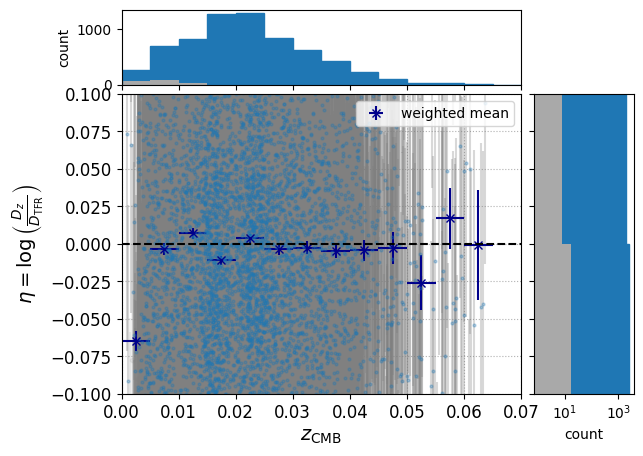

In [48]:
zbins = np.arange(0, 0.105, 0.005)
dz = 0.5*np.diff(zbins)
zc = 0.5*(zbins[1:] + zbins[:-1])

sample1 = ~outlier_boolean
sample2 = outlier_boolean

fig = plt.figure()

gs = fig.add_gridspec(2, 2, width_ratios=(4,1), height_ratios=(1,4), left=0.1, right=0.9, bottom=0.1, top=0.9, wspace=0.05, hspace=0.05)

ax = fig.add_subplot(gs[1,0])

ax.errorbar(cf4['Z_CMB'][sample2], 
             cf4['LOGDIST'][sample2], 
             # xerr=cf4['ZERR_DESI'][sample2], 
             yerr=cf4['LOGDIST_ERR'][sample2],
             fmt='.', 
             color='gray',
             alpha=0.1, 
             ecolor='gray')

ax.errorbar(cf4['Z_CMB'][sample1], 
             cf4['LOGDIST'][sample1], 
             # xerr=cf4['ZERR_DESI'][sample1], 
             yerr=cf4['LOGDIST_ERR'][sample1],
             fmt='.', 
             markersize=4, 
             alpha=0.3,
             color='tab:blue',
             ecolor='gray')

# Plot the weighted mean
N, y_avg, y_std = profile_histogram(cf4['Z_CMB'][sample1], 
                                    cf4['LOGDIST'][sample1], 
                                    zbins, 
                                    weights=cf4['LOGDIST_ERR'][sample1]**-2, 
                                    weighted=True)
ax.errorbar(zc, y_avg, xerr=dz, yerr=y_std, fmt='x', color='darkblue', label='weighted mean')
'''
# Plot the median
N, y_avg, y_std = profile_histogram(cf4['Z_CMB'][sample1], 
                                    cf4['R_LOGDIST'][sample1], 
                                    zbins, 
                                    median=True)
ax.errorbar(zc, y_avg, xerr=dz, yerr=y_std, fmt='x', color='lightsteelblue', label='median')
'''
# Line at eta = 0
ax.hlines(0, 0, 0.2, linestyles='dashed', colors='k', zorder=5)

ax.legend()

ax.grid(ls=':')

plt.tick_params(axis='both', which='major', labelsize=12)

ax.set_xlabel(r'$z_{\text{CMB}}$', fontsize=14)
ax.set_ylabel(r'$\eta = \log \left( \frac{D_z}{D_{\text{TFR}}} \right)$', fontsize=14)

# ax.set_ylim((-1.9, 1.9))
# ax.set_xlim((0, 0.2))
# ax.set_ylim((-0.5, 0.5))
ax.set_ylim((-0.1, 0.1))
ax.set_xlim((0, 0.07))

ax.grid(ls=':')


ax_histx = fig.add_subplot(gs[0,0], sharex=ax)
ax_histx.hist(cf4['Z_CMB'][sample1], 
              color='tab:blue',
              bins=np.arange(0, 0.07, 0.005))
ax_histx.hist(cf4['Z_CMB'][sample2], 
              bins=np.arange(0, 0.07, 0.005), 
              color='darkgray')
ax_histx.hist(cf4['Z_CMB'][sample1], 
              bins=np.arange(0, 0.07, 0.005), 
              color='tab:blue', 
              histtype='step')

ax_histx.tick_params(axis='x', labelbottom=False)
ax_histx.set_ylabel('count')


ax_histy = fig.add_subplot(gs[1,1], sharey=ax)
ax_histy.hist(cf4['LOGDIST'][sample1], 
              bins=np.arange(-2, 2, 0.1),
              color='tab:blue',
              orientation='horizontal')
ax_histy.hist(cf4['LOGDIST'][sample2], 
              bins=np.arange(-2, 2, 0.1), 
              color='darkgray', 
              orientation='horizontal')
ax_histy.hist(cf4['LOGDIST'][sample1], 
              bins=np.arange(-2, 2, 0.1), 
              orientation='horizontal', 
              histtype='step',
              color='tab:blue')

ax_histy.set_xscale('log')
ax_histy.tick_params(axis='y', labelleft=False)
ax_histy.set_xlabel('count');

# plt.savefig('../../Figures/Y1/iron_logdist-v-z_jointTFR-varyV0-perpdwarfs_z0p1_Anthony2_weightsVmax-1_dVsys_20250717.png', 
#             dpi=150, 
#             facecolor='none', 
#             bbox_inches='tight');

/tmp/ipykernel_2003104/65690152.py:27: RuntimeWarning: invalid value encountered in log10
  deltamarray = np.log10(dzarray/dharray)


(0.0, 0.07)

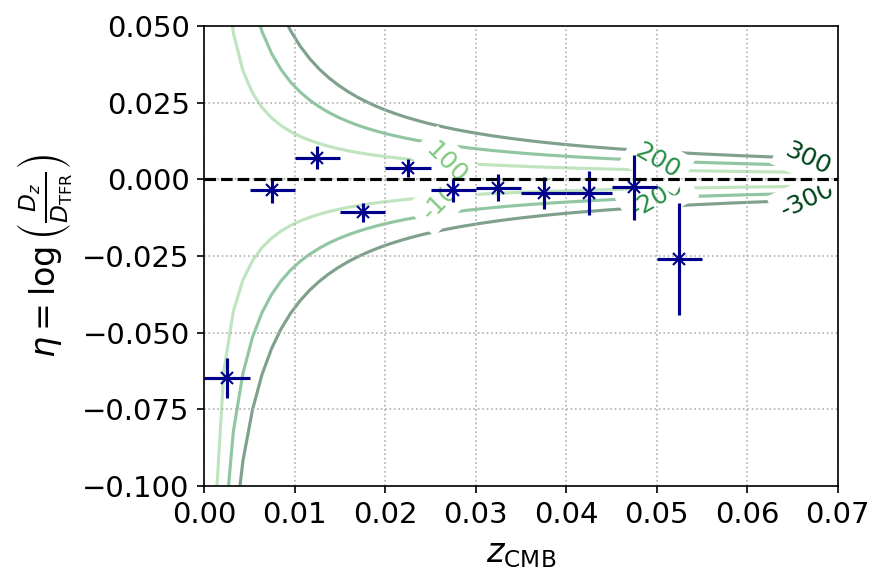

In [49]:
plt.figure(tight_layout=True, dpi=150, facecolor='none', figsize=(6,4))

# zbins = np.arange(0, 0.1025, 0.0025)
zbins = np.arange(0, 0.06, 0.005)
dz = 0.5*np.diff(zbins)
zc = 0.5*(zbins[1:] + zbins[:-1])

sample1=cf4['MAIN']
# sample1=~outlier_boolean
N, y_avg, y_std = profile_histogram(cf4['Z_CMB'][sample1], 
                                    cf4['LOGDIST'][sample1], 
                                    zbins, 
                                    weights=cf4['LOGDIST_ERR'][sample1]**-2, 
                                    weighted=True)
plt.errorbar(zc, y_avg, xerr=dz, yerr=y_std, fmt='x', color='darkblue', label='Main sample')



# PV lines (code taken from Cullen)
c = const.c.to('km/s')
velarray = np.arange(-300, 301, 100)
zarray = np.linspace(0.00005, 0.21, 200)

dzarray = cosmo.comoving_distance(zarray).value
dharray = cosmo.comoving_distance(np.outer(1.0/(1.0 + velarray/c.value), 
								  (1.0 + zarray)) - 1.0).value
deltamarray = np.log10(dzarray/dharray)

rotation = [25.0, 30.0, 45.0, 0.0, -45.0, -30.0, -25.0]
labels = ["-300", "-200", "-100", "0", "100", "200", "300"]
xcoord = np.array([20000.0, 15000.0, 8000.0, -1000.0, 8000.0, 15000.0, 20000.0])
coord = np.searchsorted(zarray, xcoord/c.value)
ycoord = np.array([deltamarray[i,j] for i, j in enumerate(coord)])

colors = 0.8*np.fabs(velarray)/np.amax(np.fabs(velarray)) + 0.2

for v in range(len(velarray)):
    col = plt.cm.Greens(colors[v])

    plt.plot(zarray, deltamarray[v,:], 
             color=col, 
             linestyle='-', 
             alpha=0.5, 
             zorder=0)

    if (v != 3):
        plt.text(xcoord[v]/c.value, ycoord[v], 
                 labels[v], 
                 color=col, 
                 fontsize=12, 
                 rotation=rotation[v], 
                 ha="center", 
                 va="center", 
                 bbox=dict(boxstyle="square", ec="w", fc="w"), 
                 zorder=1)

# Line at eta = 0
plt.hlines(0, 0, 0.2, linestyles='dashed', colors='k', zorder=5)
#-------------------------------------------------------------------------------

plt.grid(ls=':')

# plt.vlines([0.03, 0.1], -0.05, 0.05, colors='gray', linestyles='dashed')

plt.tick_params(axis='both', which='major', labelsize=14)

plt.xlabel(r'$z_{\text{CMB}}$', fontsize=16)
plt.ylabel(r'$\eta = \log \left( \frac{D_z}{D_{\text{TFR}}} \right)$', 
           fontsize=16)

# plt.ylim((-0.12, 0.05))
# plt.ylim((-0.12, 0.1))
plt.ylim((-0.1, 0.05))
plt.xlim((0, 0.07))
# plt.xlim((0, 0.2))

# plt.legend(loc='lower right');

# plt.savefig('/pscratch/sd/s/sgmoore1/TF/figures/TFR_DR2_v3_eta_z.png',facecolor='none', dpi=150)

In [ ]:
# # Create a single column to denote which objects should be used for cosmological analysis
# cf4['OUTLIER'] = outlier_boolean
# cf4['MAIN'] = ~cf4['OUTLIER']

In [50]:
np.sum(cf4['MAIN'])/len(cf4)

0.9765105628600975

In [ ]:
# cf4['MAIN'] = cf4['MAIN'].filled(False)
# cf4['GOOD_MORPH'] = cf4['GOOD_MORPH'].filled(False)

In [51]:
cf4.write('/pscratch/sd/s/sgmoore1/TF/cats/TF_calibration_v5_CF4_dwarfcut.fits', 
             overwrite=True)

# Compare to CF4's own measurements

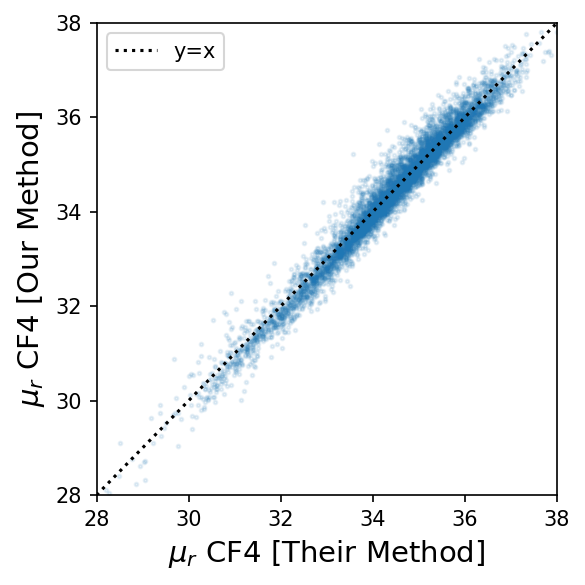

In [52]:
plt.figure(tight_layout=True, facecolor='none', dpi=150, figsize=(4,4))
plt.scatter(cf4['DM-r'], cf4['MU_TF'], s=3, alpha=0.1, color='tab:blue')
plt.plot([28,38],[28,38], ls='dotted', color='k', label='y=x')
# plt.plot([28,38],([28,38]+5*np.log10(0.75)), ls='dashed', color='k', label=r'$y=x+5\log (0.75)$')
plt.xlim(28,38)
plt.ylim(28,38)
plt.xlabel(r'$\mu_r$ CF4 [Their Method]', fontsize=14)
plt.ylabel(r'$\mu_r$ CF4 [Our Method]', fontsize=14)
plt.legend()
plt.show()

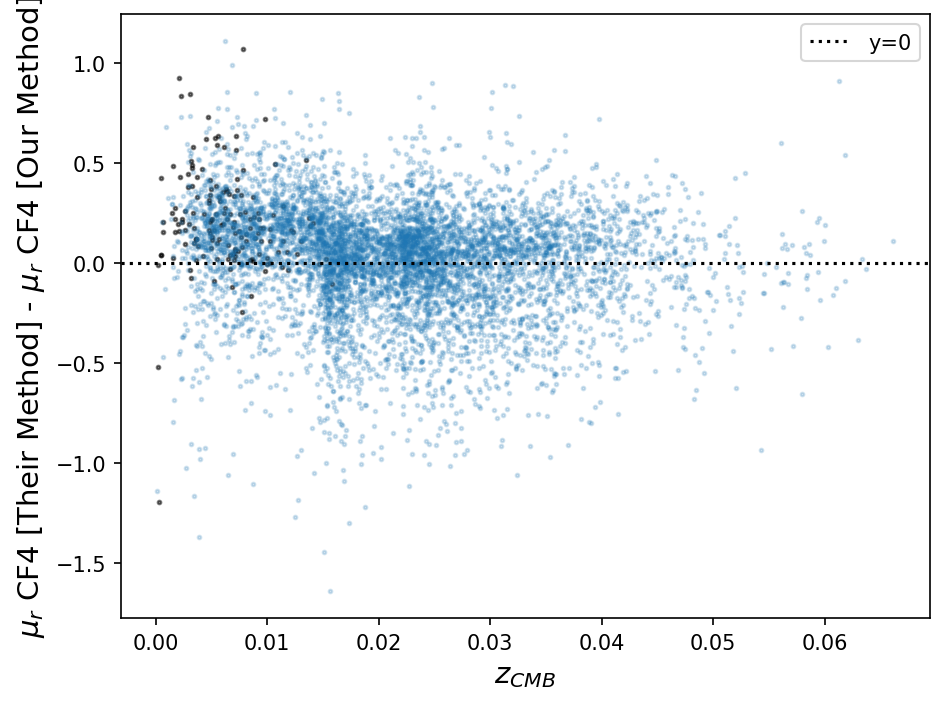

In [53]:
plt.figure(tight_layout=True, facecolor='none', dpi=150,)
plt.scatter(cf4['Z_CMB'][~cf4['MAIN']], cf4['DM-r'][~cf4['MAIN']] - cf4['MU_TF'][~cf4['MAIN']], s=3, alpha=0.5, color='k')
plt.scatter(cf4['Z_CMB'][cf4['MAIN']], cf4['DM-r'][cf4['MAIN']] - cf4['MU_TF'][cf4['MAIN']], s=3, alpha=0.2, color='tab:blue')
plt.axhline(y=0, ls='dotted', color='k', label='y=0')
# plt.axhline(y=-5*np.log10(0.75), ls='dashed', color='k', label=r'$y=-5\log (0.75)$')
# plt.xlim(28,38)
# # plt.ylim(28,38)
plt.xlabel(r'$z_{CMB}$', fontsize=14)
plt.ylabel(r'$\mu_r$ CF4 [Their Method] - $\mu_r$ CF4 [Our Method]', fontsize=14)
plt.legend()
plt.show()

In [54]:
## Calculate eta for CF4 using their methodology
cf4['CF4_LOGDIST'] = 0.2*(cf4['MU_ZCMB'] - cf4['DM-r'])
cf4['CF4_LOGDIST_ERR'] = 0.2*cf4['e_DM-r']

/tmp/ipykernel_2003104/2862047120.py:35: RuntimeWarning: invalid value encountered in log10
  deltamarray = np.log10(dzarray/dharray)


(0.0, 0.07)

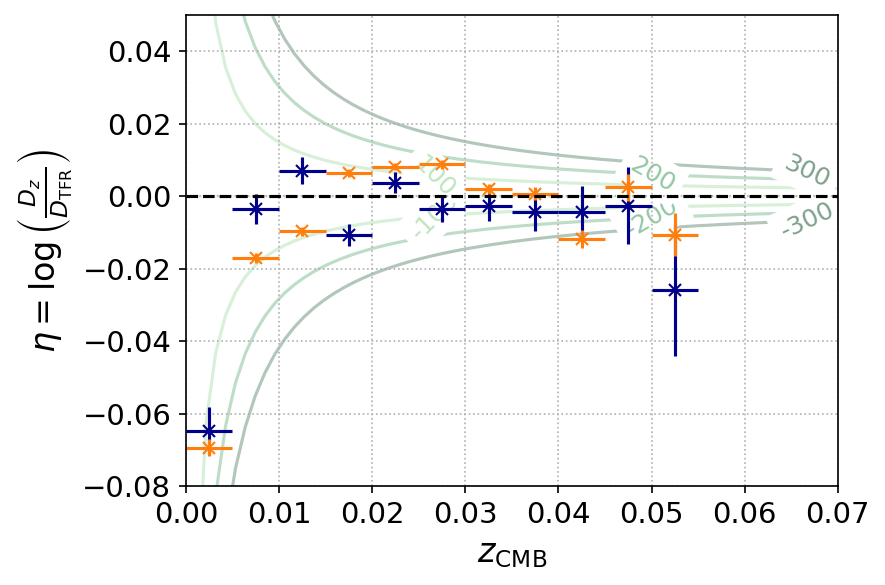

In [63]:
plt.figure(tight_layout=True, dpi=150, facecolor='none', figsize=(6,4))

# zbins = np.arange(0, 0.1025, 0.0025)
zbins = np.arange(0, 0.06, 0.005)
dz = 0.5*np.diff(zbins)
zc = 0.5*(zbins[1:] + zbins[:-1])

sample1=cf4['MAIN']
# sample1=~outlier_boolean
N, y_avg, y_std = profile_histogram(cf4['Z_CMB'][sample1], 
                                    cf4['LOGDIST'][sample1], 
                                    zbins, 
                                    weights=cf4['LOGDIST_ERR'][sample1]**-2, 
                                    weighted=True)
plt.errorbar(zc, y_avg, xerr=dz, yerr=y_std, fmt='x', color='darkblue', label='Our method')


N, y_avg, y_std = profile_histogram(cf4['Z_CMB'][sample1], 
                                    cf4['CF4_LOGDIST'][sample1], 
                                    zbins, 
                                    weights=cf4['CF4_LOGDIST_ERR'][sample1]**-2, 
                                    weighted=True)
plt.errorbar(zc, y_avg, xerr=dz, yerr=y_std, fmt='x', color='tab:orange', label='Their method')



# PV lines (code taken from Cullen)
c = const.c.to('km/s')
velarray = np.arange(-300, 301, 100)
zarray = np.linspace(0.00005, 0.21, 200)

dzarray = cosmo.comoving_distance(zarray).value
dharray = cosmo.comoving_distance(np.outer(1.0/(1.0 + velarray/c.value), 
								  (1.0 + zarray)) - 1.0).value
deltamarray = np.log10(dzarray/dharray)

rotation = [25.0, 30.0, 45.0, 0.0, -45.0, -30.0, -25.0]
labels = ["-300", "-200", "-100", "0", "100", "200", "300"]
xcoord = np.array([20000.0, 15000.0, 8000.0, -1000.0, 8000.0, 15000.0, 20000.0])
coord = np.searchsorted(zarray, xcoord/c.value)
ycoord = np.array([deltamarray[i,j] for i, j in enumerate(coord)])

colors = 0.8*np.fabs(velarray)/np.amax(np.fabs(velarray)) + 0.2

for v in range(len(velarray)):
    col = plt.cm.Greens(colors[v])

    plt.plot(zarray, deltamarray[v,:], 
             color=col, 
             linestyle='-', 
             alpha=0.3, 
             zorder=0)

    if (v != 3):
        plt.text(xcoord[v]/c.value, ycoord[v], 
                 labels[v], 
                 color=col, 
                 alpha=0.5,
                 fontsize=12, 
                 rotation=rotation[v], 
                 ha="center", 
                 va="center", 
                 bbox=dict(boxstyle="square", ec="w", fc="w"), 
                 zorder=1)

# Line at eta = 0
plt.hlines(0, 0, 0.2, linestyles='dashed', colors='k', zorder=5)
#-------------------------------------------------------------------------------

plt.grid(ls=':')

# plt.vlines([0.03, 0.1], -0.05, 0.05, colors='gray', linestyles='dashed')

plt.tick_params(axis='both', which='major', labelsize=14)

plt.xlabel(r'$z_{\text{CMB}}$', fontsize=16)
plt.ylabel(r'$\eta = \log \left( \frac{D_z}{D_{\text{TFR}}} \right)$', 
           fontsize=16)

# plt.ylim((-0.12, 0.05))
# plt.ylim((-0.12, 0.1))
plt.ylim((-0.08, 0.05))
plt.xlim((0, 0.07))
# plt.xlim((0, 0.2))

# plt.legend(loc='lower right');

# plt.savefig('/pscratch/sd/s/sgmoore1/TF/figures/TFR_DR2_v3_eta_z.png',facecolor='none', dpi=150)

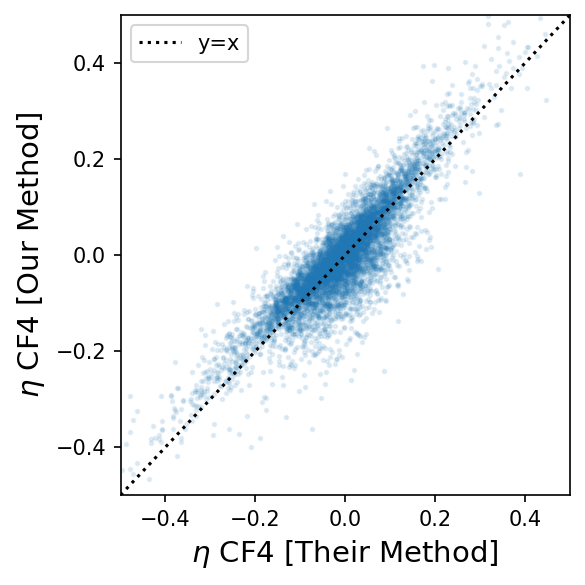

In [64]:
plt.figure(tight_layout=True, facecolor='none', dpi=150, figsize=(4,4))
plt.scatter(cf4['CF4_LOGDIST'], cf4['LOGDIST'], s=3, alpha=0.1, color='tab:blue')
plt.plot([-0.5,0.5],[-0.5,0.5], ls='dotted', color='k', label='y=x')
# plt.plot([28,38],([28,38]+5*np.log10(0.75)), ls='dashed', color='k', label=r'$y=x+5\log (0.75)$')
plt.xlim(-0.5,0.5)
plt.ylim(-0.5,0.5)
plt.xlabel(r'$\eta$ CF4 [Their Method]', fontsize=14)
plt.ylabel(r'$\eta$ CF4 [Our Method]', fontsize=14)
plt.legend()
plt.show()

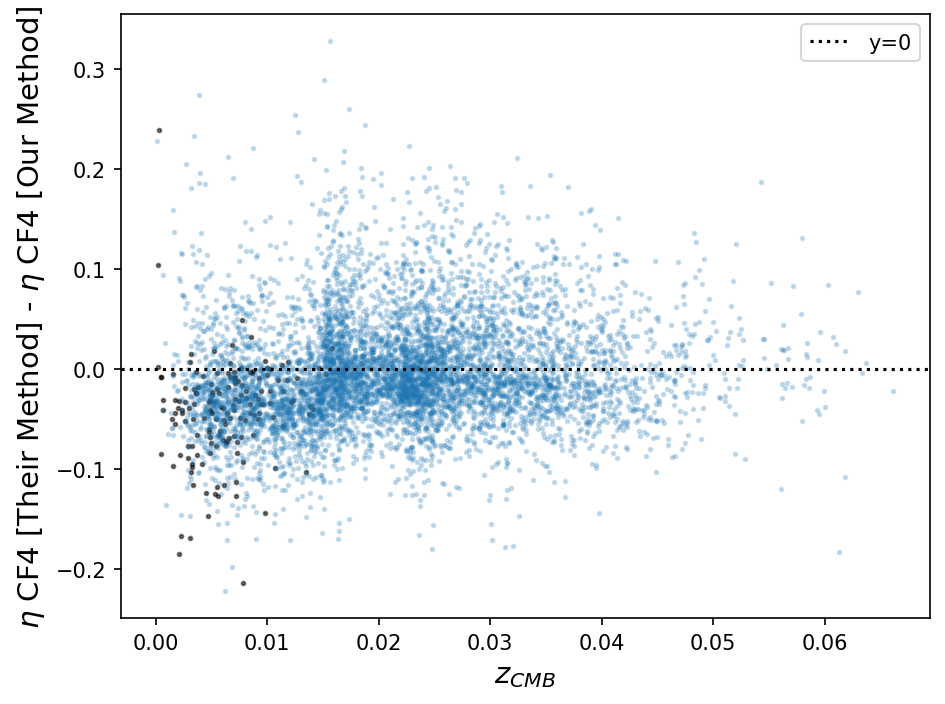

In [66]:
plt.figure(tight_layout=True, facecolor='none', dpi=150,)
plt.scatter(cf4['Z_CMB'][~cf4['MAIN']], cf4['CF4_LOGDIST'][~cf4['MAIN']] - cf4['LOGDIST'][~cf4['MAIN']], s=3, alpha=0.5, color='k')
plt.scatter(cf4['Z_CMB'][cf4['MAIN']], cf4['CF4_LOGDIST'][cf4['MAIN']] - cf4['LOGDIST'][cf4['MAIN']], s=3, alpha=0.2, color='tab:blue')
plt.axhline(y=0, ls='dotted', color='k', label='y=0')
# plt.axhline(y=-5*np.log10(0.75), ls='dashed', color='k', label=r'$y=-5\log (0.75)$')
# plt.xlim(28,38)
# # plt.ylim(28,38)
plt.xlabel(r'$z_{CMB}$', fontsize=14)
plt.ylabel(r'$\eta$ CF4 [Their Method] - $\eta$ CF4 [Our Method]', fontsize=14)
plt.legend()
plt.show()

In [72]:
# plt.figure(tight_layout=True, facecolor='none', dpi=150,)
# plt.scatter(cf4['Z_CMB'][~cf4['MAIN']], (cf4['CF4_LOGDIST'][~cf4['MAIN']] - cf4['LOGDIST'][~cf4['MAIN']])/(cf4['CF4_LOGDIST'][~cf4['MAIN']]), s=3, alpha=0.5, color='k')
# plt.scatter(cf4['Z_CMB'][cf4['MAIN']], (cf4['CF4_LOGDIST'][cf4['MAIN']] - cf4['LOGDIST'][cf4['MAIN']])/(cf4['CF4_LOGDIST'][cf4['MAIN']]), s=3, alpha=0.2, color='tab:blue')
# plt.axhline(y=0, ls='dotted', color='k', label='y=0')
# # plt.axhline(y=-5*np.log10(0.75), ls='dashed', color='k', label=r'$y=-5\log (0.75)$')
# # plt.xlim(28,38)
# plt.ylim(-1,1)
# plt.xlabel(r'$z_{CMB}$', fontsize=14)
# plt.ylabel(r'$\Delta \eta / \eta_{CF4}$ ', fontsize=14)
# plt.legend()
# plt.show()